# Task 3 – Multi-Stage Stochastic Programming Policy
**Decision Making under Uncertainty – Spring 2026 | Part B**

This notebook implements the complete SP policy:
1. System parameters (`get_fixed_data`)
2. Stochastic process models (price + occupancy)
3. Scenario generation
4. Pyomo MILP builder (constraints, overrule controllers, inertia)
5. Policy wrapper matching the `PolicyRestaurant2` template
6. Quick sanity-check / smoke test


In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyomo.environ import (
    ConcreteModel, Set, Param, Var, Objective, Constraint, Block,
    SolverFactory, NonNegativeReals, minimize, Binary, value
)
from pyomo.opt import TerminationCondition


## 1. System Parameters

In [147]:
def get_fixed_data():
    """
    Returns the fixed system characteristics.
    THIS FUNCTION SHOULD NOT BE CHANGED.
    """
    num_timeslots = 10
    return {
        'num_timeslots'              : num_timeslots,
        'initial_temperature'        : 21.0,
        'previous_initial_temperature': 21.0,
        'initial_humidity'           : 40.0,
        'heating_max_power'          : 3.0,       # Pr  (kW)
        'heat_exchange_coeff'        : 0.6,        # ζ_exch
        'heating_efficiency_coeff'   : 1.0,        # ζ_conv
        'thermal_loss_coeff'         : 0.1,        # ζ_loss
        'heat_vent_coeff'            : 0.7,        # ζ_cool
        'heat_occupancy_coeff'       : 0.02,       # ζ_occ
        'temp_min_comfort_threshold' : 18.0,       # T_low
        'temp_OK_threshold'          : 22.0,       # T_OK
        'temp_max_comfort_threshold' : 26.0,       # T_high
        'humidity_threshold'         : 70.0,       # H_high
        'vent_min_up_time'           : 3,          # 3 hour ventilation time
        'ventilation_power'          : 2.0,        # P_vent (kW)
        'humidity_occupancy_coeff'   : 0.18,       # η_occ
        'humidity_vent_coeff'        : 15.0,       # η_vent
        'outdoor_temperature'        : [
            3 * np.sin(2 * np.pi * t / num_timeslots - np.pi / 2)
            for t in range(num_timeslots)
        ],
    }

DATA = get_fixed_data()
print("System parameters loaded.")
print(f"  Horizon     : {DATA['num_timeslots']} hours")
print(f"  Max heating : {DATA['heating_max_power']} kW per room")
print(f"  T_low / T_OK / T_high : "
      f"{DATA['temp_min_comfort_threshold']} / "
      f"{DATA['temp_OK_threshold']} / "
      f"{DATA['temp_max_comfort_threshold']} °C")


System parameters loaded.
  Horizon     : 10 hours
  Max heating : 3.0 kW per room
  T_low / T_OK / T_high : 18.0 / 22.0 / 26.0 °C


## 2. Stochastic Process Models
From `PriceProcessRestaurant` and `OccupancyProcessRestaurant`.

In [148]:
# ── Electricity price process (AR(2)-like with mean reversion) ────────────────
def price_model(current_price, previous_price, rng=None):
    """
    One-step-ahead price sample.

    Parameters
    ----------
    current_price  : float  – price at t
    previous_price : float  – price at t-1
    rng            : numpy Generator (optional); uses np.random if None

    Returns
    -------
    float – sampled price at t+1
    """
    mean_price         = 4.0
    reversion_strength = 0.12
    price_cap          = 12.0
    price_floor        = 0.0

    mean_reversion = reversion_strength * (mean_price - current_price)
    noise          = (rng.normal(0, 0.5) if rng is not None
                      else np.random.normal(0, 0.5))

    next_price = (current_price
                  + 0.6 * (current_price - previous_price)
                  + mean_reversion
                  + noise)

    if next_price < 0:
        rand_val = rng.random() if rng is not None else np.random.rand()
        if rand_val > 0.2:
            next_price = (rng.uniform(0, mean_price * 0.3) if rng is not None
                          else np.random.uniform(0, mean_price * 0.3))

    return float(np.clip(next_price, price_floor, price_cap))


# ── Occupancy process (coupled mean-reverting, one room per step) ─────────────
def next_occupancy_levels(r1_current, r2_current, rng=None):
    """
    One-step-ahead occupancy sample for both rooms.

    Returns
    -------
    (r1_next, r2_next) : (float, float)
    """
    mean_r1, mean_r2 = 35.0, 25.0
    rev              = 0.25
    coupling         = 0.1

    noise_r1 = (rng.normal(0, 3.0) if rng is not None
                else np.random.normal(0, 3.0))
    noise_r2 = (rng.normal(0, 2.5) if rng is not None
                else np.random.normal(0, 2.5))

    r1_next = (r1_current
               + rev      * (mean_r1 - r1_current)
               + coupling * (r2_current - r1_current)
               + noise_r1)

    r2_next = (r2_current
               + rev      * (mean_r2 - r2_current)
               + coupling * (r1_current - r2_current)
               + noise_r2)

    return float(np.clip(r1_next, 20, 50)), float(np.clip(r2_next, 10, 30))


print("Process models defined: price_model(), next_occupancy_levels()")


Process models defined: price_model(), next_occupancy_levels()


## 3. Scenario Generation

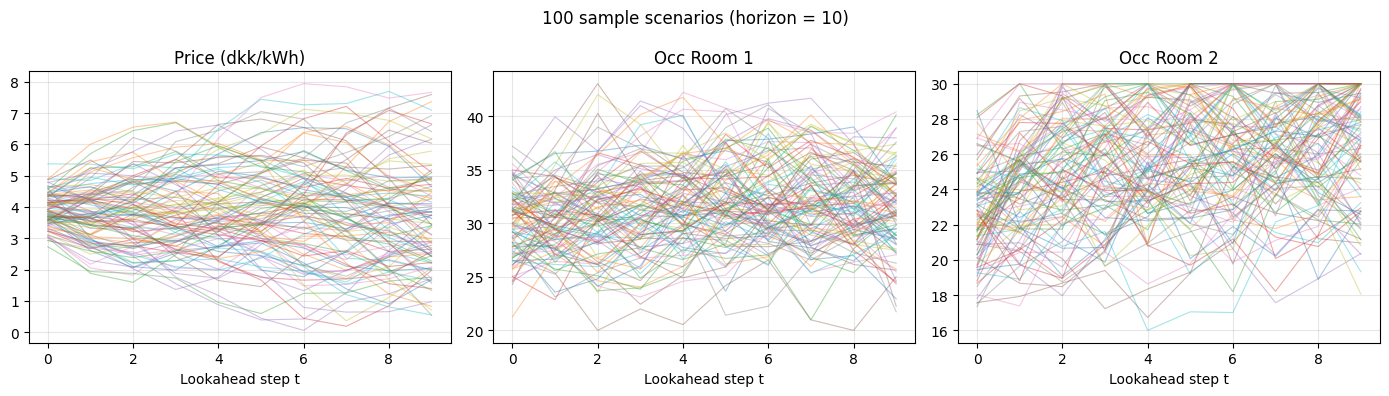

Scenario generation OK.


In [149]:
def generate_scenarios(price_now, price_prev,
                        occ_r1_now, occ_r2_now,
                        horizon, n_scenarios, rng):
    """
    Draw *n_scenarios* independent sample paths over *horizon* steps,
    starting from the current observed state.

    Returns
    -------
    price_dict   : {(t, s): float}        – price at lookahead step t, scenario s
    occ_dict     : {(r, t, s): float}     – occupancy of room r
    hum_occ_dict : {(t, s): float}        – total occupancy (both rooms)
    """
    price_dict   = {}
    occ_dict     = {}
    hum_occ_dict = {}

    for s in range(n_scenarios):
        p_cur,  p_prev  = price_now,   price_prev
        o1_cur, o2_cur  = occ_r1_now,  occ_r2_now

        for t in range(horizon):
            p_next          = price_model(p_cur, p_prev, rng)
            o1_next, o2_next = next_occupancy_levels(o1_cur, o2_cur, rng)

            price_dict[t, s]   = p_next
            occ_dict[1, t, s]  = o1_next
            occ_dict[2, t, s]  = o2_next
            hum_occ_dict[t, s] = o1_next + o2_next

            p_prev, p_cur   = p_cur,  p_next
            o1_cur, o2_cur  = o1_next, o2_next

    return price_dict, occ_dict, hum_occ_dict


# ── Quick visualisation of generated scenarios ────────────────────────────────
_rng_preview = np.random.default_rng(0)
scenarios_to_generate = 100

price_dict, occ_dict, hum_occ_dict = generate_scenarios(
    price_now=4.0, price_prev=4.0,
    occ_r1_now=30.0, occ_r2_now=20.0,
    horizon=10, n_scenarios=scenarios_to_generate,
    rng=_rng_preview
)



fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for s in range(scenarios_to_generate):
    axes[0].plot([price_dict[t, s] for t in range(10)], alpha=0.4, lw=0.8)
    axes[1].plot([occ_dict[1, t, s] for t in range(10)], alpha=0.4, lw=0.8)
    axes[2].plot([occ_dict[2, t, s] for t in range(10)], alpha=0.4, lw=0.8)

for ax, title in zip(axes, ['Price (dkk/kWh)', 'Occ Room 1', 'Occ Room 2']):
    ax.set_xlabel('Lookahead step t')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'{scenarios_to_generate} sample scenarios (horizon = 10)', fontsize=12)
plt.tight_layout()
plt.show()
print("Scenario generation OK.")


## 3.a 2 stage Clustering



In [150]:
# Cluster scenarios into 20 representative ones using k-means (on price and total occupancy) and visualise
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

n_clusters = 20

# Change from K means to hierarchical clustering (AgglomerativeClustering) 
def cluster_scenarios(price_dict, occ_dict, n_clusters, horizon, scenarios_to_generate):
    
    scaler = StandardScaler()
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    #horizon = DATA['num_timeslots']

    X = np.array([
            [price_dict[t, s] for t in range(horizon)] +
            [occ_dict[1, t, s] for t in range(horizon)] +
            [occ_dict[2, t, s] for t in range(horizon)]
            for s in range(scenarios_to_generate)
        ])

    X_scaled = scaler.fit_transform(X)

    # K means clustering

    km = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    km.fit(X_scaled)

    labels        = km.labels_
    cluster_sizes = np.bincount(labels)
    probabilities = cluster_sizes / scenarios_to_generate

    # Unpack vector into dictonaries that Pyomo can use
    centroids = scaler.inverse_transform(km.cluster_centers_)

    price_dict_clus   = {}
    occ_dict_clus     = {}
    hum_occ_dict_clus = {}

    for s in range(n_clusters):
        for t in range(horizon):
            price_dict_clus[t, s]   = float(np.clip(centroids[s, t],                0, 12))
            occ_dict_clus[1, t, s]  = float(np.clip(centroids[s, horizon + t],   20, 50))
            occ_dict_clus[2, t, s]  = float(np.clip(centroids[s, 2*horizon + t], 10, 30))
            hum_occ_dict_clus[t, s] = occ_dict_clus[1, t, s] + occ_dict_clus[2, t, s]

    return price_dict_clus, occ_dict_clus, hum_occ_dict_clus, probabilities, X, labels, centroids


#RUN CLUSTERING
price_dict_clus, occ_dict_clus, hum_occ_dict_clus, probabilities, X, labels, centroids = cluster_scenarios(
    price_dict, occ_dict, n_clusters=20, horizon=DATA['num_timeslots'], scenarios_to_generate=scenarios_to_generate
)

print(f"Raw scenarios: {scenarios_to_generate}")
print(f"Clustered scenarios: {n_clusters}")
print(f"Cluster sizes: {np.bincount(labels)}")
print(f"Cluster probabilities: {probabilities}")
print(f"Sum of probabilities: {probabilities.sum()}")



Raw scenarios: 100
Clustered scenarios: 20
Cluster sizes: [ 3 13  6  6  2  3  6  9 11  4  9  5  4  3  4  2  1  4  1  4]
Cluster probabilities: [0.03 0.13 0.06 0.06 0.02 0.03 0.06 0.09 0.11 0.04 0.09 0.05 0.04 0.03
 0.04 0.02 0.01 0.04 0.01 0.04]
Sum of probabilities: 1.0000000000000002


C:\Users\mauri\AppData\Local\Temp\ipykernel_28472\713805710.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap     = plt.cm.get_cmap('tab20', n_clusters)


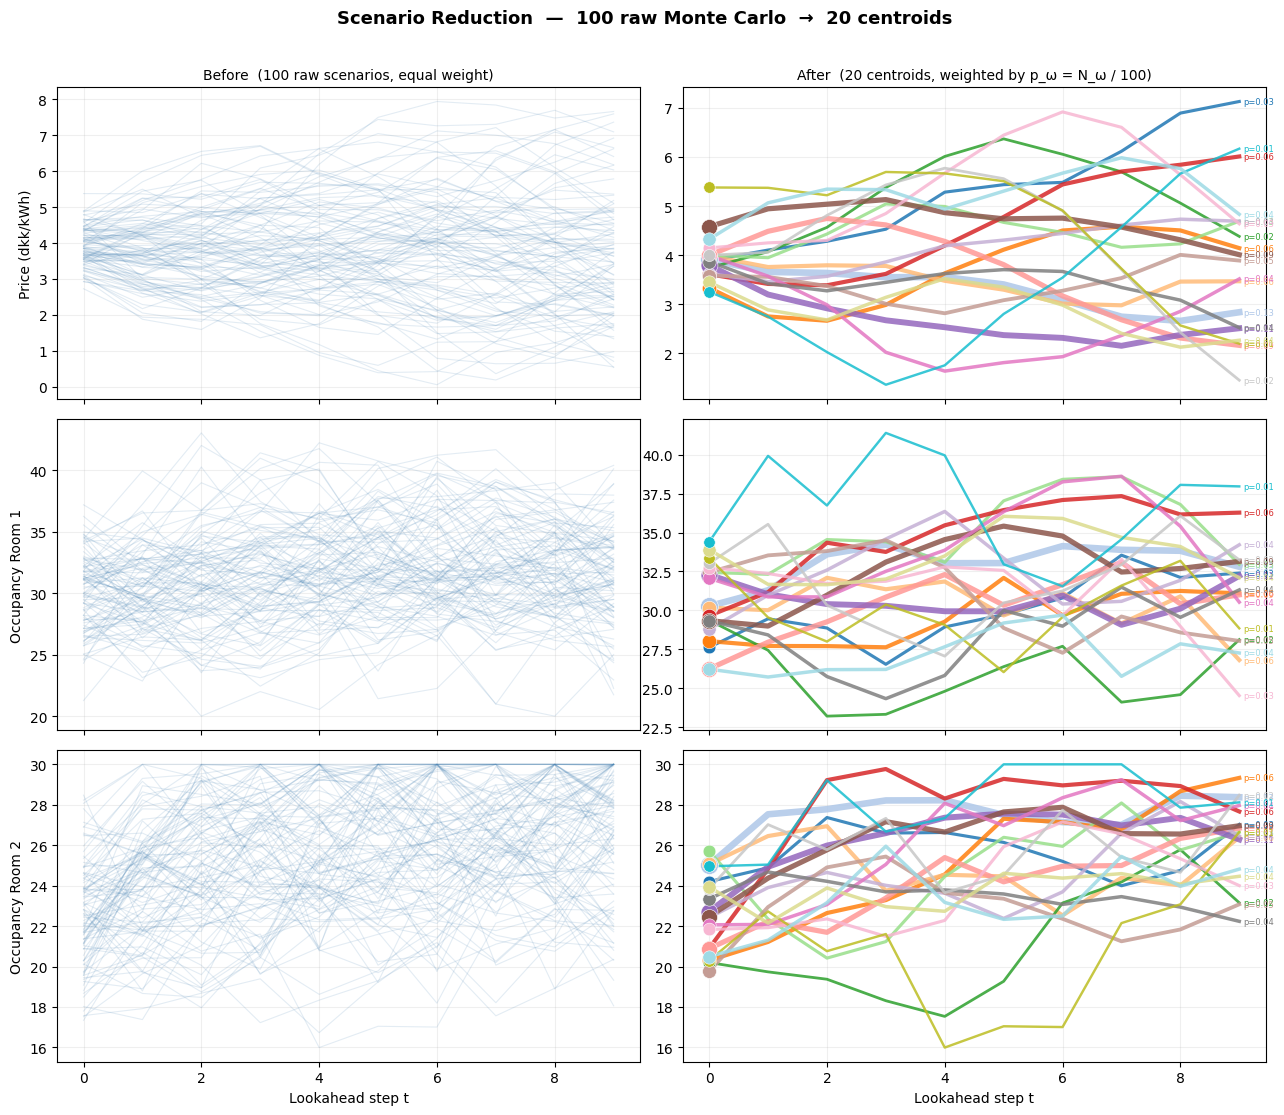

In [151]:
# ── Plot: before vs after ─────────────────────────────────────────────────────
cmap     = plt.cm.get_cmap('tab20', n_clusters)
t_axis   = np.arange(DATA['num_timeslots'])
features = [
    ('Price (dkk/kWh)',    0),
    ('Occupancy Room 1', DATA['num_timeslots']),
    ('Occupancy Room 2', 2 * DATA['num_timeslots']),
]

fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
fig.suptitle(
    f"Scenario Reduction  —  {scenarios_to_generate} raw Monte Carlo  →  {n_clusters} centroids",
    fontsize=13, fontweight='bold', y=1.01
)

for row, (feat_label, offset) in enumerate(features):

    # ── LEFT: raw scenarios ───────────────────────────────────────────────────
    ax_raw = axes[row, 0]
    for s in range(scenarios_to_generate):
        traj = X[s, offset : offset + DATA['num_timeslots']]
        ax_raw.plot(t_axis, traj, color='steelblue', alpha=0.15, lw=0.8)

    ax_raw.set_ylabel(feat_label)
    ax_raw.grid(True, alpha=0.2)
    if row == 0:
        ax_raw.set_title(f'Before  ({scenarios_to_generate} raw scenarios, equal weight)', fontsize=10)
    if row == 2:
        ax_raw.set_xlabel('Lookahead step t')

    # ── RIGHT: centroids only, coloured + sized by probability ────────────────
    ax_clus = axes[row, 1]
    for s in range(n_clusters):
        traj = centroids[s, offset : offset + DATA['num_timeslots']]
        p    = probabilities[s]
        ax_clus.plot(t_axis, traj,
                     color=cmap(s),
                     lw=1.5 + p * 25,
                     alpha=0.85)
        ax_clus.scatter(0, traj[0],
                        s=60 + p * 800,
                        color=cmap(s), zorder=5, edgecolors='white', lw=0.4)
        ax_clus.annotate(
            f'p={p:.2f}',
            xy=(t_axis[-1], traj[-1]),
            fontsize=6, color=cmap(s),
            xytext=(3, 0), textcoords='offset points', va='center',
        )

    ax_clus.grid(True, alpha=0.2)
    if row == 0:
        ax_clus.set_title(
            f'After  ({n_clusters} centroids, weighted by p_ω = N_ω / {scenarios_to_generate})',
            fontsize=10)
    if row == 2:
        ax_clus.set_xlabel('Lookahead step t')

plt.tight_layout()
plt.show()

## 3.b Multistage clustering 

In [152]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

def cluster_scenarios_tree(price_dict, occ_dict, n_branches, horizon, scenarios_to_generate):
    """
    Builds a scenario tree by recursive conditional K-Means clustering.
    
    At each stage t, clusters the t-th observation within each group of 
    scenarios that shared the same node at t-1.
    
    Returns
    -------
    tree : dict
        node_id -> {
            't'           : int,         # stage (0 = root)
            'parent'      : int or None, # parent node id
            'children'    : list[int],   # child node ids
            'scenarios'   : list[int],   # raw scenario indices in this node
            'centroid'    : dict,        # {'price': float, 'occ1': float, 'occ2': float}
            'cond_prob'   : float,       # P(this node | parent)
            'path_prob'   : float,       # P(root -> this node)
        }
    """

    # --- Root node: contains all scenarios, no centroid needed ---
    tree = {}
    tree[0] = {
        't'         : 0,
        'parent'    : None,
        'children'  : [],
        'scenarios' : list(range(scenarios_to_generate)),
        'centroid'  : None,
        'cond_prob' : 1.0,
        'path_prob' : 1.0,
    }

    node_counter = 1

    # nodes_at_current_stage: list of node_ids whose children we need to create
    nodes_at_current_stage = [0]

    for t in range(horizon):

        nodes_at_next_stage = []

        for parent_id in nodes_at_current_stage:

            parent_node     = tree[parent_id]
            member_scenarios = parent_node['scenarios']
            n_parent        = len(member_scenarios)

            # Gracefully handle nodes with fewer scenarios than n_branches
            k = min(n_branches, n_parent)

            # --- Feature matrix: only the t-th observation ---
            X_t = np.array([
                [price_dict[t, s],
                 occ_dict[1, t, s],
                 occ_dict[2, t, s]]
                for s in member_scenarios
            ])

            scaler = StandardScaler()
            X_t_scaled = scaler.fit_transform(X_t)

            km = KMeans(n_clusters=k, n_init=20, random_state=42)
            km.fit(X_t_scaled)

            centroids_raw = scaler.inverse_transform(km.cluster_centers_)

            # --- Create one child node per cluster ---
            for cluster_label in range(k):

                child_scenarios = [
                    s for s, lbl in zip(member_scenarios, km.labels_)
                    if lbl == cluster_label
                ]

                cond_prob = len(child_scenarios) / n_parent
                path_prob = parent_node['path_prob'] * cond_prob

                c = centroids_raw[cluster_label]
                centroid = {
                    'price' : float(np.clip(c[0],  0, 12)),
                    'occ1'  : float(np.clip(c[1], 20, 50)),
                    'occ2'  : float(np.clip(c[2], 10, 30)),
                }
                centroid['hum_occ'] = centroid['occ1'] + centroid['occ2']

                child_id = node_counter
                tree[child_id] = {
                    't'         : t + 1,
                    'parent'    : parent_id,
                    'children'  : [],
                    'scenarios' : child_scenarios,
                    'centroid'  : centroid,
                    'cond_prob' : cond_prob,
                    'path_prob' : path_prob,
                }
                tree[parent_id]['children'].append(child_id)
                nodes_at_next_stage.append(child_id)
                node_counter += 1

        nodes_at_current_stage = nodes_at_next_stage

    return tree

In [153]:
def print_scenario_tree(tree, n_branches, horizon):
    PIPE   = "│   "
    BRANCH = "├── "
    LAST   = "└── "
    BLANK  = "    "

    # ── summary header ──────────────────────────────────────────
    leaf_nodes     = [nid for nid, n in tree.items() if not n['children']]
    internal_nodes = len(tree) - len(leaf_nodes) - 1  # exclude root

    print("=" * 60)
    print("  Scenario Tree Summary")
    print("=" * 60)
    print(f"  Branches per node  : {n_branches}")
    print(f"  Horizon (stages)   : {horizon}")
    print(f"  Total nodes        : {len(tree)}  (root + {internal_nodes} internal + {len(leaf_nodes)} leaves)")
    print(f"  Scenarios (raw)    : {len(tree[0]['scenarios'])}")
    print(f"  Path prob sum      : {sum(tree[nid]['path_prob'] for nid in leaf_nodes):.4f}  (should be 1.0)")
    print("=" * 60)
    print()

    # ── recursive tree printer ───────────────────────────────────
    def _node_line(node_id, prefix, is_last):
        node      = tree[node_id]
        connector = LAST if is_last else BRANCH

        if node_id == 0:
            print(f"{prefix}{connector}[root]  t=0  all scenarios  S={len(node['scenarios'])}")
        else:
            tag = "[leaf]" if not node['children'] else "[node]"
            c   = node['centroid']
            print(f"{prefix}{connector}{tag}  id={node_id:3d}  t={node['t']}"
                  f"  S={len(node['scenarios']):3d}"
                  f"  cond={node['cond_prob']:.3f}  path={node['path_prob']:.4f}"
                  f"  │  price={c['price']:5.2f}  occ={c['hum_occ']:5.1f}")

        extension = BLANK if is_last else PIPE
        children  = node['children']
        for i, child_id in enumerate(children):
            _node_line(child_id, prefix + extension, is_last=(i == len(children) - 1))

    _node_line(0, prefix="", is_last=True)

    # ── leaf summary table ───────────────────────────────────────
    print()
    print("-" * 60)
    print(f"  {'Leaf id':>7}  {'t':>3}  {'S':>4}  {'path_prob':>9}  {'price':>6}  {'hum_occ':>7}")
    print("-" * 60)
    for nid in leaf_nodes:
        n, c = tree[nid], tree[nid]['centroid']
        print(f"  {nid:>7}  {n['t']:>3}  {len(n['scenarios']):>4}"
              f"  {n['path_prob']:>9.4f}  {c['price']:>6.2f}  {c['hum_occ']:>7.1f}")
    print("-" * 60)
    print(f"  {'SUM':>7}  {'':>3}  {'':>4}  {sum(tree[nid]['path_prob'] for nid in leaf_nodes):>9.4f}")
    print("=" * 60)

# ── Build and print the scenario tree ─────────────────────────────────────────
n_branches = 3
scenario_tree = cluster_scenarios_tree(
    price_dict, occ_dict, n_branches=n_branches,
    horizon=DATA['num_timeslots'], scenarios_to_generate=scenarios_to_generate
)

print_scenario_tree(scenario_tree, n_branches=n_branches, horizon=DATA['num_timeslots'])

  Scenario Tree Summary
  Branches per node  : 3
  Horizon (stages)   : 10
  Total nodes        : 703  (root + 602 internal + 100 leaves)
  Scenarios (raw)    : 100
  Path prob sum      : 1.0000  (should be 1.0)

└── [root]  t=0  all scenarios  S=100
    ├── [node]  id=  1  t=1  S= 37  cond=0.370  path=0.3700  │  price= 4.40  occ= 51.7
    │   ├── [node]  id=  4  t=2  S= 13  cond=0.351  path=0.1300  │  price= 4.22  occ= 54.0
    │   │   ├── [node]  id= 13  t=3  S=  5  cond=0.385  path=0.0500  │  price= 3.82  occ= 51.4
    │   │   │   ├── [node]  id= 40  t=4  S=  2  cond=0.400  path=0.0200  │  price= 3.76  occ= 59.3
    │   │   │   │   ├── [node]  id=106  t=5  S=  1  cond=0.500  path=0.0100  │  price= 3.63  occ= 57.8
    │   │   │   │   │   └── [node]  id=203  t=6  S=  1  cond=1.000  path=0.0100  │  price= 3.46  occ= 56.0
    │   │   │   │   │       └── [node]  id=303  t=7  S=  1  cond=1.000  path=0.0100  │  price= 3.15  occ= 56.7
    │   │   │   │   │           └── [node]  id=403  t=8 

## 4a. Deterministic MILP Builder

In [154]:

def build_lookahead_model(current_state, price_dict, occ_dict, hum_occ_dict,
                   horizon):
    """
    Build the deterministic MILP for the lookahead policy.

    Parameters
    ----------
    current_state : dict with keys
        T_in_r1      – current temperature room 1  (°C)
        T_in_r2      – current temperature room 2  (°C)
        humidity     – current humidity             (%)
        vent_prev    – ventilation status at t-1    (0 or 1)
        vent_on_count– consecutive hours vent has been ON (for inertia)
    price_dict    : {(t,s): float}
    occ_dict      : {(r,t,s): float}
    hum_occ_dict  : {(t,s): float}
    horizon       : int

    Returns
    -------
    Pyomo ConcreteModel (unsolved)
    """
    d  = DATA
    M  = 200.0          # big-M constant (larger than any realistic T or H range)

    T_init = {1: current_state['T_in_r1'], 2: current_state['T_in_r2']}
    H_init = current_state['humidity']
    v_prev = int(current_state['vent_prev'])
    v_on_h = int(current_state.get('vent_on_count', 0))

    m = ConcreteModel()

    # ── Sets ──────────────────────────────────────────────────────────────────
    m.R   = Set(initialize=[1, 2])
    m.T   = Set(initialize=list(range(horizon)))
    m.RT = m.R * m.T 
    # ── Parameters ────────────────────────────────────────────────────────────
    m.Pr    = Param(initialize=d['heating_max_power'])
    m.Zexch = Param(initialize=d['heat_exchange_coeff'])
    m.Zconv = Param(initialize=d['heating_efficiency_coeff'])
    m.Zloss = Param(initialize=d['thermal_loss_coeff'])
    m.Zcool = Param(initialize=d['heat_vent_coeff'])
    m.Zocc  = Param(initialize=d['heat_occupancy_coeff'])
    m.Tmin  = Param(initialize=d['temp_min_comfort_threshold'])
    m.Tok   = Param(initialize=d['temp_OK_threshold'])
    m.Thigh = Param(initialize=d['temp_max_comfort_threshold'])
    m.Hhigh = Param(initialize=d['humidity_threshold'])
    m.Pvent = Param(initialize=d['ventilation_power'])
    m.Hocc  = Param(initialize=d['humidity_occupancy_coeff'])
    m.Hvent = Param(initialize=d['humidity_vent_coeff'])
    m.Tout  = Param(m.T, initialize={t: d['outdoor_temperature'][t]
                                      for t in range(horizon)})

    m.O      = Param(m.RT, initialize=occ_dict)
    m.prices = Param(m.T,  initialize=price_dict)
    m.HumOcc = Param(m.T,  initialize=hum_occ_dict)

    # ── Decision variables ────────────────────────────────────────────────────
    m.Heat = Var(m.RT, domain=NonNegativeReals, bounds=(0, d['heating_max_power']))
    m.Vent = Var(m.T,  domain=Binary)
    m.Uon  = Var(m.T,  domain=Binary)   # ventilation start-up indicator
    m.Uoff = Var(m.T,  domain=Binary)   # ventilation shut-down indicator

    # ── Auxiliary binary variables for overrule controllers ───────────────────
    m.u = Var(m.RT, domain=Binary)   # 1 → low-temp overrule active
    m.w = Var(m.RT, domain=Binary)   # 1 → temperature has recovered to T_OK
    m.y = Var(m.RT, domain=Binary)   # 1 → high-temp overrule active

    # ── State variables ───────────────────────────────────────────────────────
    m.T_in = Var(m.RT, domain=NonNegativeReals)
    m.Hum  = Var(m.T,  domain=NonNegativeReals)

    # ── Temperature dynamics ──────────────────────────────────────────────────
    def temp_dynamics(m, r, t):
        if t == 0:
            return m.T_in[r, t] == T_init[r]
        tp = t - 1
        other_r = 2 if r == 1 else 1
        return m.T_in[r, t] == (
            m.T_in[r, tp]
            + m.Zexch * (m.T_in[other_r, tp] - m.T_in[r, tp ])
            + m.Zloss * (m.Tout[tp]              - m.T_in[r, tp])
            + m.Zconv * m.Heat[r, tp]
            - m.Zcool * m.Vent[tp]
            + m.Zocc  * m.O[r, tp]
        )
    m.TempDyn = Constraint(m.RT, rule=temp_dynamics)

    # ── Humidity dynamics ─────────────────────────────────────────────────────
    def hum_dynamics(m, t):
        if t == 0:
            return m.Hum[t] == H_init
        tp = t - 1
        return m.Hum[t] == (
            m.Hum[tp]
            - m.Hvent * m.Vent[tp]
            + m.Hocc  * m.HumOcc[tp]
        )
    m.HumDyn = Constraint(m.T, rule=hum_dynamics)

    # ── Overrule controller: LOW temperature ──────────────────────────────────
    # u[r,t,s] = 1  iff  overrule is active (T < T_low or still recovering)
    # w[r,t,s] = 1  iff  T has reached T_OK this step (deactivates overrule)

    def u_activation(m, r, t):
        # T_in >= T_low - M*u  →  u forced to 1 when T < T_low
        return m.T_in[r, t] >= m.Tmin - M * m.u[r, t]
    m.UActivation = Constraint(m.RT, rule=u_activation)

    def w_deactivation(m, r, t):
        # T_in >= T_OK - M*(1-w)  →  w forced to 1 when T >= T_OK
        return m.T_in[r, t] >= m.Tok - M * (1 - m.w[r, t])
    m.WDeactivation = Constraint(m.RT, rule=w_deactivation)

    def u_persistence(m, r, t):
        # Overrule persists: u[t] >= u[t-1] - w[t]
        if t == 0:
            m.u[r, t].fix(0)
            m.w[r, t].fix(0)
            return Constraint.Skip
        return m.u[r, t] >= m.u[r, t - 1] - m.w[r, t]
    m.UPersistence = Constraint(m.RT, rule=u_persistence)

    def heat_max_when_overrule(m, r, t):
        # u = 1  →  Heat = Pr
        return m.Heat[r, t] >= m.Pr * m.u[r, t]
    m.HeatMaxOverrule = Constraint(m.RT, rule=heat_max_when_overrule)

    # ── Overrule controller: HIGH temperature ─────────────────────────────────
    def y_activation(m, r, t):
        # T_in <= T_high + M*y  →  y forced to 1 when T > T_high
        return m.T_in[r, t] <= m.Thigh + M * m.y[r, t]
    m.YActivation = Constraint(m.RT, rule=y_activation)

    def heat_off_when_overrule(m, r, t):
        # y = 1  →  Heat = 0
        return m.Heat[r, t] <= m.Pr * (1 - m.y[r, t])
    m.HeatOffOverrule = Constraint(m.RT, rule=heat_off_when_overrule)

    # ── Humidity overrule: force ventilation ON ───────────────────────────────
    def vent_humidity_overrule(m, t):
        # Hum <= H_high + M*v  →  v forced to 1 when Hum > H_high
        return m.Hum[t] <= m.Hhigh + M * m.Vent[t]
    m.VentHumOverrule = Constraint(m.T, rule=vent_humidity_overrule)

    # ── Ventilation inertia: 3-hour minimum ON time ───────────────────────────
    def on_off_exclusivity(m, t):
        return m.Uon[t] + m.Uoff[t] <= 1
    m.OnOffExcl = Constraint(m.T, rule=on_off_exclusivity)

    def uoff_bound(m, t):
        return m.Uoff[t] <= 1 - m.Vent[t]
    m.UoffBound = Constraint(m.T, rule=uoff_bound)

    def uon_bound(m, t):
        return m.Uon[t] <= 1 - m.Vent[t]
    m.UonBound = Constraint(m.T, rule=uon_bound)

    def min_uptime(m, t):
        L         = 3
        remaining = [k for k in range(t, t + L) if k <= m.T.last()]
        v_p       = v_prev if t == 0 else m.Vent[t - 1]
        return (sum(m.Vent[k] for k in remaining)
                >= len(remaining) * (m.Vent[t] - v_p))
    m.MinUptime = Constraint(m.T, rule=min_uptime)

    # Carry over inertia commitment from previous real-system hours
    if v_prev == 1 and v_on_h < 3:
        forced_on = 3 - v_on_h
        for t in range(min(forced_on, horizon)):
            m.Vent[t].fix(1)


    # ── Objective: minimise expected electricity cost ─────────────────────────
    def objective(m):
        return sum(m.prices[t] * (sum(m.Heat[r, t] for r in m.R)+ m.Vent[t] * m.Pvent)for t in m.T)
            
    m.obj = Objective(rule=objective, sense=minimize)

    return m


print("build_lookahead_model() defined.")

build_lookahead_model() defined.


## 4b. Stochastic MILP Builder

In [155]:
def build_sp_model(current_state, price_dict, occ_dict, hum_occ_dict,
                   horizon, n_scenarios, probabilities):
    """
    Build the stochastic MILP for the SP policy.

    Parameters
    ----------
    current_state : dict with keys
        T_in_r1      – current temperature room 1  (°C)
        T_in_r2      – current temperature room 2  (°C)
        humidity     – current humidity             (%)
        vent_prev    – ventilation status at t-1    (0 or 1)
        vent_on_count– consecutive hours vent has been ON (for inertia)
    price_dict    : {(t,s): float}
    occ_dict      : {(r,t,s): float}
    hum_occ_dict  : {(t,s): float}
    horizon       : int
    n_scenarios   : int

    Returns
    -------
    Pyomo ConcreteModel (unsolved)
    """
    d  = DATA
    M  = 200.0          # big-M constant (larger than any realistic T or H range)

    T_init = {1: current_state['T_in_r1'], 2: current_state['T_in_r2']}
    H_init = current_state['humidity']
    v_prev = int(current_state['vent_prev'])
    v_on_h = int(current_state.get('vent_on_count', 0))

    m = ConcreteModel()

    # ── Sets ──────────────────────────────────────────────────────────────────
    m.R   = Set(initialize=[1, 2])
    m.T   = Set(initialize=list(range(horizon)))
    m.S   = Set(initialize=list(range(n_scenarios)))
    m.RTS = m.R * m.T * m.S
    m.TS  = m.T * m.S

    # ── Parameters ────────────────────────────────────────────────────────────
    m.Pr    = Param(initialize=d['heating_max_power'])
    m.Zexch = Param(initialize=d['heat_exchange_coeff'])
    m.Zconv = Param(initialize=d['heating_efficiency_coeff'])
    m.Zloss = Param(initialize=d['thermal_loss_coeff'])
    m.Zcool = Param(initialize=d['heat_vent_coeff'])
    m.Zocc  = Param(initialize=d['heat_occupancy_coeff'])
    m.Tmin  = Param(initialize=d['temp_min_comfort_threshold'])
    m.Tok   = Param(initialize=d['temp_OK_threshold'])
    m.Thigh = Param(initialize=d['temp_max_comfort_threshold'])
    m.Hhigh = Param(initialize=d['humidity_threshold'])
    m.Pvent = Param(initialize=d['ventilation_power'])
    m.Hocc  = Param(initialize=d['humidity_occupancy_coeff'])
    m.Hvent = Param(initialize=d['humidity_vent_coeff'])
    m.Tout  = Param(m.T, initialize={t: d['outdoor_temperature'][t] for t in range(horizon)})
    m.pi = Param(m.S, initialize={s: probabilities[s] for s in range(n_scenarios)})

    m.O      = Param(m.RTS, initialize=occ_dict)
    m.prices = Param(m.TS,  initialize=price_dict)
    m.HumOcc = Param(m.TS,  initialize=hum_occ_dict)

    # ── Decision variables ────────────────────────────────────────────────────
    m.Heat = Var(m.RTS, domain=NonNegativeReals, bounds=(0, d['heating_max_power']))
    m.Vent = Var(m.TS,  domain=Binary)
    m.Uon  = Var(m.TS,  domain=Binary)   # ventilation start-up indicator
    m.Uoff = Var(m.TS,  domain=Binary)   # ventilation shut-down indicator

    # ── Auxiliary binary variables for overrule controllers ───────────────────
    m.u = Var(m.RTS, domain=Binary)   # 1 → low-temp overrule active
    m.w = Var(m.RTS, domain=Binary)   # 1 → temperature has recovered to T_OK
    m.y = Var(m.RTS, domain=Binary)   # 1 → high-temp overrule active

    # ── State variables ───────────────────────────────────────────────────────
    m.T_in = Var(m.RTS, domain=NonNegativeReals)
    m.Hum  = Var(m.TS,  domain=NonNegativeReals)

    # ── Temperature dynamics ──────────────────────────────────────────────────
    def temp_dynamics(m, r, t, s):
        if t == 0:
            return m.T_in[r, t, s] == T_init[r]
        tp = t - 1
        other_r = 2 if r == 1 else 1
        return m.T_in[r, t, s] == (
            m.T_in[r, tp, s]
            + m.Zexch * (m.T_in[other_r, tp, s] - m.T_in[r, tp, s])
            + m.Zloss * (m.Tout[tp]              - m.T_in[r, tp, s])
            + m.Zconv * m.Heat[r, tp, s]
            - m.Zcool * m.Vent[tp, s]
            + m.Zocc  * m.O[r, tp, s]
        )
    m.TempDyn = Constraint(m.RTS, rule=temp_dynamics)

    # ── Humidity dynamics ─────────────────────────────────────────────────────
    def hum_dynamics(m, t, s):
        if t == 0:
            return m.Hum[t, s] == H_init
        tp = t - 1
        return m.Hum[t, s] == (
            m.Hum[tp, s]
            - m.Hvent * m.Vent[tp, s]
            + m.Hocc  * m.HumOcc[tp, s]
        )
    m.HumDyn = Constraint(m.TS, rule=hum_dynamics)

    # ── Overrule controller: LOW temperature ──────────────────────────────────
    # u[r,t,s] = 1  iff  overrule is active (T < T_low or still recovering)
    # w[r,t,s] = 1  iff  T has reached T_OK this step (deactivates overrule)

    def u_activation(m, r, t, s):
        # T_in >= T_low - M*u  →  u forced to 1 when T < T_low
        return m.T_in[r, t, s] >= m.Tmin - M * m.u[r, t, s]
    m.UActivation = Constraint(m.RTS, rule=u_activation)

    def w_deactivation(m, r, t, s):
        # T_in >= T_OK - M*(1-w)  →  w forced to 1 when T >= T_OK
        return m.T_in[r, t, s] >= m.Tok - M * (1 - m.w[r, t, s])
    m.WDeactivation = Constraint(m.RTS, rule=w_deactivation)

    def u_persistence(m, r, t, s):
        # Overrule persists: u[t] >= u[t-1] - w[t]
        if t == 0:
            m.u[r, t, s].fix(0)
            m.w[r, t, s].fix(0)
            return Constraint.Skip
        return m.u[r, t, s] >= m.u[r, t - 1, s] - m.w[r, t, s]
    m.UPersistence = Constraint(m.RTS, rule=u_persistence)

    def heat_max_when_overrule(m, r, t, s):
        # u = 1  →  Heat = Pr
        return m.Heat[r, t, s] >= m.Pr * m.u[r, t, s]
    m.HeatMaxOverrule = Constraint(m.RTS, rule=heat_max_when_overrule)

    # ── Overrule controller: HIGH temperature ─────────────────────────────────
    def y_activation(m, r, t, s):
        # T_in <= T_high + M*y  →  y forced to 1 when T > T_high
        return m.T_in[r, t, s] <= m.Thigh + M * m.y[r, t, s]
    m.YActivation = Constraint(m.RTS, rule=y_activation)

    def heat_off_when_overrule(m, r, t, s):
        # y = 1  →  Heat = 0
        return m.Heat[r, t, s] <= m.Pr * (1 - m.y[r, t, s])
    m.HeatOffOverrule = Constraint(m.RTS, rule=heat_off_when_overrule)

    # ── Humidity overrule: force ventilation ON ───────────────────────────────
    def vent_humidity_overrule(m, t, s):
        # Hum <= H_high + M*v  →  v forced to 1 when Hum > H_high
        return m.Hum[t, s] <= m.Hhigh + M * m.Vent[t, s]
    m.VentHumOverrule = Constraint(m.TS, rule=vent_humidity_overrule)

    # ── Ventilation inertia: 3-hour minimum ON time ───────────────────────────
    def on_off_exclusivity(m, t, s):
        return m.Uon[t, s] + m.Uoff[t, s] <= 1
    m.OnOffExcl = Constraint(m.TS, rule=on_off_exclusivity)

    def uoff_bound(m, t, s):
        return m.Uoff[t, s] <= 1 - m.Vent[t, s]
    m.UoffBound = Constraint(m.TS, rule=uoff_bound)

    def uon_bound(m, t, s):
        return m.Uon[t, s] <= 1 - m.Vent[t, s]
    m.UonBound = Constraint(m.TS, rule=uon_bound)

    def min_uptime(m, t, s):
        L         = 3
        remaining = [k for k in range(t, t + L) if k <= m.T.last()]
        v_p       = v_prev if t == 0 else m.Vent[t - 1, s]
        return (sum(m.Vent[k, s] for k in remaining)
                >= len(remaining) * (m.Vent[t, s] - v_p))
    m.MinUptime = Constraint(m.TS, rule=min_uptime)

    # Carry over inertia commitment from previous real-system hours
    if v_prev == 1 and v_on_h < 3:
        forced_on = 3 - v_on_h
        for t in range(min(forced_on, horizon)):
            for s in range(n_scenarios):
                m.Vent[t, s].fix(1)

    # ── Non-anticipativity at t = 0 (here-and-now decisions) ─────────────────
    # All scenarios must agree on the first-stage action.
    def heat_na(m, r, s1, s2):
        if s1 >= s2:
            return Constraint.Skip
        return m.Heat[r, 0, s1] == m.Heat[r, 0, s2]
    m.HeatNA = Constraint(m.R, m.S, m.S, rule=heat_na)

    def vent_na(m, s1, s2):
        if s1 >= s2:
            return Constraint.Skip
        return m.Vent[0, s1] == m.Vent[0, s2]
    m.VentNA = Constraint(m.S, m.S, rule=vent_na)

    # ── Objective: minimise expected electricity cost ─────────────────────────
    def objective(m):
        return sum(
            m.pi[s] * sum(
                m.prices[t, s] * (
                    sum(m.Heat[r, t, s] for r in m.R)
                    + m.Vent[t, s] * m.Pvent
                )
                for t in m.T
            )
            for s in m.S
        )
    m.obj = Objective(rule=objective, sense=minimize)

    return m


print("build_sp_model() defined.")


build_sp_model() defined.


## 4.c Multistage Stochastic Builder

In [156]:
def build_multisp_model(current_state, tree, horizon):
    """
    Build the stochastic MILP for the Multi-Stage SP policy.

    Parameters
    ----------
    current_state : dict with keys
        T_in_r1       - current temperature room 1  (°C)
        T_in_r2       - current temperature room 2  (°C)
        humidity      - current humidity             (%)
        vent_prev     - ventilation status at t-1    (0 or 1)
        vent_on_count - consecutive hours vent ON    (for inertia)
    tree     : dict returned by cluster_scenarios_tree()
               node_id -> {t, parent, children, scenarios,
                           centroid, cond_prob, path_prob}
    horizon  : int

    Returns
    -------
    Pyomo ConcreteModel (unsolved)
    """
    d = DATA
    M = 200.0

    T_init = {1: current_state['T_in_r1'], 2: current_state['T_in_r2']}
    H_init = current_state['humidity']
    v_prev = int(current_state['vent_prev'])
    v_on_h = int(current_state.get('vent_on_count', 0))

    # ═══════════════════════════════════════════════════════════════════════
    # CHANGE 1: Pre-compute node lists from the tree dict
    #
    # WHY: In 2-stage we had a flat list of scenario indices 0..K-1.
    #      Now our index universe is node IDs from the tree.
    #      We need three subsets:
    #      - all_nodes      : every node (used for state variables and dynamics)
    #      - internal_nodes : nodes that have children (decisions happen here)
    #      - leaf_nodes     : nodes with no children (used in objective)
    #
    # Decisions (Heat, Vent) are made at internal nodes because those are
    # the points where the controller acts. Leaf nodes are terminal — no
    # decision is made there, they only contribute cost to the objective.
    # ═══════════════════════════════════════════════════════════════════════
    all_nodes      = list(tree.keys())
    internal_nodes = [nid for nid, n in tree.items() if n['children']]
    leaf_nodes     = [nid for nid, n in tree.items() if not n['children']]

    # ═══════════════════════════════════════════════════════════════════════
    # CHANGE 2: Build lookup dictionaries for exogenous data indexed by node
    #
    # WHY: In 2-stage, exogenous data was price_dict[t, s] and occ_dict[r,t,s].
    #      Now each node already carries its centroid (the representative
    #      value of price and occupancy at that node's stage). We extract
    #      these into flat dicts keyed by node_id so Pyomo Params can be
    #      initialised from them directly.
    #
    # The root node (id=0) has centroid=None because t=0 is the initial
    # state before any scenario realisation — we skip it with the 'if'.
    # ═══════════════════════════════════════════════════════════════════════
    price_by_node   = {nid: tree[nid]['centroid']['price']
                       for nid in all_nodes if tree[nid]['centroid'] is not None}
    occ1_by_node    = {nid: tree[nid]['centroid']['occ1']
                       for nid in all_nodes if tree[nid]['centroid'] is not None}
    occ2_by_node    = {nid: tree[nid]['centroid']['occ2']
                       for nid in all_nodes if tree[nid]['centroid'] is not None}
    humocc_by_node  = {nid: tree[nid]['centroid']['hum_occ']
                       for nid in all_nodes if tree[nid]['centroid'] is not None}

    # ═══════════════════════════════════════════════════════════════════════
    # CHANGE 3: path_prob replaces marginal probabilities
    #
    # WHY: In 2-stage, probabilities[s] was the marginal probability of
    #      scenario s (cluster_size / total_scenarios).
    #      In multi-stage, probability only makes sense for complete paths
    #      (root to leaf). path_prob is the product of conditional branch
    #      probabilities along the path. Only leaf nodes get a path_prob
    #      because only leaf nodes represent complete realisations.
    # ═══════════════════════════════════════════════════════════════════════
    path_prob_by_leaf = {nid: tree[nid]['path_prob'] for nid in leaf_nodes}

    m = ConcreteModel()

    # ── Sets ─────────────────────────────────────────────────────────────────

    m.R = Set(initialize=[1, 2])

    # CHANGE: T and S are replaced by node-based sets.
    # N      = all nodes  (state variables live here)
    # N_int  = internal nodes only  (decision variables live here)
    # N_leaf = leaf nodes only  (objective weights live here)
    m.N      = Set(initialize=all_nodes)
    m.N_int  = Set(initialize=internal_nodes)
    m.N_leaf = Set(initialize=leaf_nodes)

    # R × N_int cross-product set (replaces the old R × T × S set).
    # Used for per-room decision variables that are indexed by room and node.
    m.RN_int = m.R * m.N_int

    # ── Parameters ───────────────────────────────────────────────────────────
    # Physical parameters — unchanged from 2-stage
    m.Pr    = Param(initialize=d['heating_max_power'])
    m.Zexch = Param(initialize=d['heat_exchange_coeff'])
    m.Zconv = Param(initialize=d['heating_efficiency_coeff'])
    m.Zloss = Param(initialize=d['thermal_loss_coeff'])
    m.Zcool = Param(initialize=d['heat_vent_coeff'])
    m.Zocc  = Param(initialize=d['heat_occupancy_coeff'])
    m.Tmin  = Param(initialize=d['temp_min_comfort_threshold'])
    m.Tok   = Param(initialize=d['temp_OK_threshold'])
    m.Thigh = Param(initialize=d['temp_max_comfort_threshold'])
    m.Hhigh = Param(initialize=d['humidity_threshold'])
    m.Pvent = Param(initialize=d['ventilation_power'])
    m.Hocc  = Param(initialize=d['humidity_occupancy_coeff'])
    m.Hvent = Param(initialize=d['humidity_vent_coeff'])

    # Outdoor temperature: still indexed by time step t.
    # Each node has a stage t = tree[nid]['t'], so we look up Tout[tree[nid]['t']]
    # inside constraint rules when needed.
    m.Tout = Param(initialize=lambda m: {t: d['outdoor_temperature'][t]for t in range(horizon)})

    # CHANGE: exogenous scenario data is now indexed by node_id, not (t, s).
    # Each node's centroid already holds the representative value for that
    m.prices = Param(m.N, initialize=price_by_node)
    m.HumOcc = Param(m.N, initialize=humocc_by_node)
    m.O1     = Param(m.N, initialize=occ1_by_node)
    m.O2     = Param(m.N, initialize=occ2_by_node)

    # CHANGE: path probabilities only on leaf nodes (replaces pi[s] on all S)
    m.pi = Param(m.N_leaf, initialize=path_prob_by_leaf)

    # ── Decision variables ────────────────────────────────────────────────────

    # CHANGE: Heat and Vent are now indexed by node_id, not (t, s) or (r, t, s).
    #
    # WHY: A decision is made once per node. Scenarios sharing the same node
    #      at stage t are indistinguishable up to t — they must receive the
    #      same decision. By indexing on node_id there is physically only one
    #      variable per node, so non-anticipativity holds automatically.
    #      In 2-stage we had one var per (t, s) and needed explicit NAC
    #      constraints to force agreement. Those constraints are gone now.
    m.Heat = Var(m.RN_int, domain=NonNegativeReals, bounds=(0, d['heating_max_power']))
    m.Vent = Var(m.N_int,  domain=Binary)
    m.Uon  = Var(m.N_int,  domain=Binary)
    m.Uoff = Var(m.N_int,  domain=Binary)

    # Auxiliary binary variables — same role as before, now node-indexed
    m.u = Var(m.RN_int, domain=Binary)   # low-temp overrule active
    m.w = Var(m.RN_int, domain=Binary)   # temperature recovered to T_OK
    m.y = Var(m.RN_int, domain=Binary)   # high-temp overrule active

    # ── State variables ───────────────────────────────────────────────────────

    # CHANGE: T_in and Hum are indexed over ALL nodes (not just internal).
    #
    # WHY: State variables must exist at every node because the temperature
    #      and humidity at a leaf node are needed to evaluate comfort
    #      violations (even if no decision is made at leaves). The dynamics
    #      propagate state from parent to child across every edge in the tree.
    m.T_in = Var(m.R * m.N, domain=NonNegativeReals)
    m.Hum  = Var(m.N,        domain=NonNegativeReals)

    # ── Helper: room occupancy lookup ─────────────────────────────────────────
    # Convenience function used inside constraint rules to get the right
    # occupancy param for a given room and node.
    def occ(r, nid):
        return m.O1[nid] if r == 1 else m.O2[nid]

    # ── Temperature dynamics ──────────────────────────────────────────────────

    # CHANGE: dynamics now connect parent node to child node, not (t-1,s) to (t,s).
    #
    # WHY: In 2-stage, "previous time step in the same scenario" was always
    #      (t-1, s). In the tree, the previous state is the parent node.
    #      tree[nid]['parent'] gives us that parent id directly.
    #      The root node (id=0) has no parent — it is initialised from
    #      current_state instead of from a dynamics equation.
    def temp_dynamics(m, r, nid):
        if nid == 0:
            # Root node: initialise from observed current state
            return m.T_in[r, nid] == T_init[r]

        pid      = tree[nid]['parent']        # parent node id
        other_r  = 2 if r == 1 else 1
        t_parent = tree[pid]['t']             # stage of the parent (for Tout)

        return m.T_in[r, nid] == (
            m.T_in[r, pid]
            + m.Zexch * (m.T_in[other_r, pid] - m.T_in[r, pid])
            + m.Zloss * (m.Tout[t_parent]      - m.T_in[r, pid])
            + m.Zconv * m.Heat[r, pid]          # decision at the PARENT node
            - m.Zcool * m.Vent[pid]             # decision at the PARENT node
            + m.Zocc  * occ(r, pid)             # exogenous data at parent node
        )
    m.TempDyn = Constraint(m.R * m.N, rule=temp_dynamics)

    # ── Humidity dynamics ─────────────────────────────────────────────────────

    # Same logic as temperature: parent-to-child propagation.
    def hum_dynamics(m, nid):
        if nid == 0:
            return m.Hum[nid] == H_init

        pid = tree[nid]['parent']
        return m.Hum[nid] == (
            m.Hum[pid]
            - m.Hvent * m.Vent[pid]
            + m.Hocc  * m.HumOcc[pid]
        )
    m.HumDyn = Constraint(m.N, rule=hum_dynamics)

    # ── Overrule controller: LOW temperature ─────────────────────────────────

    # CHANGE: indices are now (r, nid) instead of (r, t, s).
    # The logic is identical — only the index names change.
    def u_activation(m, r, nid):
        return m.T_in[r, nid] >= m.Tmin - M * m.u[r, nid]
    m.UActivation = Constraint(m.RN_int, rule=u_activation)

    def w_deactivation(m, r, nid):
        return m.T_in[r, nid] >= m.Tok - M * (1 - m.w[r, nid])
    m.WDeactivation = Constraint(m.RN_int, rule=w_deactivation)

    def u_persistence(m, r, nid):
        # CHANGE: "previous time step" is now the parent node.
        # If the parent is the root (no centroid), we initialise u and w to 0.
        pid = tree[nid]['parent']
        if pid == 0:
            # First real decision stage: fix overrule variables to 0
            m.u[r, nid].fix(0)
            m.w[r, nid].fix(0)
            return Constraint.Skip
        return m.u[r, nid] >= m.u[r, pid] - m.w[r, nid]
    m.UPersistence = Constraint(m.RN_int, rule=u_persistence)

    def heat_max_when_overrule(m, r, nid):
        return m.Heat[r, nid] >= m.Pr * m.u[r, nid]
    m.HeatMaxOverrule = Constraint(m.RN_int, rule=heat_max_when_overrule)

    # ── Overrule controller: HIGH temperature ─────────────────────────────────

    def y_activation(m, r, nid):
        return m.T_in[r, nid] <= m.Thigh + M * m.y[r, nid]
    m.YActivation = Constraint(m.RN_int, rule=y_activation)

    def heat_off_when_overrule(m, r, nid):
        return m.Heat[r, nid] <= m.Pr * (1 - m.y[r, nid])
    m.HeatOffOverrule = Constraint(m.RN_int, rule=heat_off_when_overrule)

    # ── Humidity overrule ─────────────────────────────────────────────────────

    def vent_humidity_overrule(m, nid):
        return m.Hum[nid] <= m.Hhigh + M * m.Vent[nid]
    m.VentHumOverrule = Constraint(m.N_int, rule=vent_humidity_overrule)

    # ── Ventilation inertia ───────────────────────────────────────────────────

    def on_off_exclusivity(m, nid):
        return m.Uon[nid] + m.Uoff[nid] <= 1
    m.OnOffExcl = Constraint(m.N_int, rule=on_off_exclusivity)

    def uoff_bound(m, nid):
        return m.Uoff[nid] <= 1 - m.Vent[nid]
    m.UoffBound = Constraint(m.N_int, rule=uoff_bound)

    def uon_bound(m, nid):
        return m.Uon[nid] <= 1 - m.Vent[nid]
    m.UonBound = Constraint(m.N_int, rule=uon_bound)

    def min_uptime(m, nid):
        # CHANGE: "next L time steps in the same scenario" is now "next L
        # nodes along the same path in the tree."
        #
        # WHY: In 2-stage we iterated t, t+1, ..., t+L-1 in scenario s.
        #      In the tree, we need to follow the descendant chain from nid.
        #      _descendants_chain() walks the first child at each stage
        #      to collect the next L nodes along one branch.
        L       = 3
        chain   = _descendants_chain(tree, nid, L)
        v_p     = v_prev if tree[nid]['parent'] == 0 else m.Vent[tree[nid]['parent']]
        return (sum(m.Vent[k] for k in chain)
                >= len(chain) * (m.Vent[nid] - v_p))
    m.MinUptime = Constraint(m.N_int, rule=min_uptime)

    # Carry over inertia from previous real-system hours.
    # CHANGE: fix Vent on all nodes at stage t < forced_on,
    # not on all (t, s) pairs.
    if v_prev == 1 and v_on_h < 3:
        forced_on = 3 - v_on_h
        for nid in internal_nodes:
            if tree[nid]['t'] <= forced_on:
                m.Vent[nid].fix(1)

    # ── NON-ANTICIPATIVITY ────────────────────────────────────────────────────
    #
    # REMOVED ENTIRELY.
    #
    # WHY: In 2-stage SP we needed explicit constraints:
    #        Heat[r, 0, s1] == Heat[r, 0, s2]  for all s1, s2
    #        Vent[0, s1]    == Vent[0, s2]      for all s1, s2
    #      because Heat and Vent were indexed by (t, s) — one variable per
    #      scenario — and we had to force them to agree at t=0.
    #
    #      In multi-stage SP, Heat[r, nid] and Vent[nid] are indexed by node.
    #      Scenarios that share the same node at stage t literally share the
    #      same variable. There is nothing to constrain: one variable = one
    #      decision = automatically the same for all scenarios passing through
    #      that node. Non-anticipativity is structural, not enforced.

    # ── Objective ─────────────────────────────────────────────────────────────

    # CHANGE: objective sums over leaf nodes weighted by path_prob,
    # and accumulates cost along the path from root to each leaf.
    #
    # WHY: In 2-stage:  obj = sum_s  pi[s] * sum_t  cost(t, s)
    #      Each scenario s had a marginal probability pi[s] and we summed
    #      cost over all (t, s) pairs.
    #
    #      In multi-stage: cost is incurred at every NODE along a path.
    #      A leaf represents a complete realisation — its path_prob is the
    #      probability of that full path occurring. We walk from each leaf
    #      back to the root, accumulating cost at each ancestor node, and
    #      weight the whole path by path_prob.
    #
    #      _path_to_root() returns the list of ancestor node ids for a leaf,
    #      excluding the root (which has no centroid / exogenous data).
    def objective(m):
        return sum(
            m.pi[leaf] * sum(
                m.prices[nid] * (
                    sum(m.Heat[r, nid] for r in m.R)
                    + m.Vent[nid] * m.Pvent
                )
                for nid in _path_to_root(tree, leaf)
            )
            for leaf in leaf_nodes
        )
    m.obj = Objective(rule=objective, sense=minimize)

    return m


# ── Tree traversal helpers ────────────────────────────────────────────────────

def _path_to_root(tree, leaf_id):
    """
    Return list of node ids from leaf back to (but not including) root.
    These are the nodes where decisions were made on this scenario's path.
    """
    path = []
    nid  = leaf_id
    while tree[nid]['parent'] is not None:
        path.append(nid)
        nid = tree[nid]['parent']
    return path


def _descendants_chain(tree, nid, L):
    """
    Return up to L successive nodes starting from nid, following the
    first child at each step. Used for the minimum-uptime window.
    """
    chain   = [nid]
    current = nid
    for _ in range(L - 1):
        children = tree[current]['children']
        if not children:
            break
        current = children[0]   # follow first branch
        chain.append(current)
    return chain


print("build_multisp_model() defined.")

build_multisp_model() defined.


## 5a. Lookahead Policy

In [157]:
lookahead_horizon = 4
gen_scenarios = 1

initial_state = {
    't'            : 0,
    'T_in_r1'      : DATA['initial_temperature'],
    'T_in_r2'      : DATA['initial_temperature'],
    'humidity'     : DATA['initial_humidity'],
    'vent_status'  : 0,
    'vent_prev'    : 0,
    'vent_on_count': 0,
    'price_now'   : 4.0,
    'price_prev'  : None,
    'occ_r1'      : 30,
    'occ_r2'      : 20,
}


def lookahead_policy(state,gen_data):
    """

    Input variables
    ---------------
t,               # current hour index (0-based, 0..9)
    T_in,            # list [T_room1 (°C), T_room2 (°C)]
    humidity,        # current humidity level (%)
    vent_status,     # ventilation ON/OFF at t-1  (0 or 1)
    vent_on_count,   # consecutive hours ventilation has been ON
    price_now,       # electricity price at current hour
    price_prev,      # electricity price at previous hour (or None at t=0)
    occ_r1,          # occupancy room 1 at current hour
    occ_r2,          # occupancy room 2 at current hour

    Design choices
    --------------
    Lookahead horizon  : H = 4 steps

    Returns
    -------
    heat_r1 : float – heating power room 1 (kW)
    heat_r2 : float – heating power room 2 (kW)
    vent    : int   – ventilation decision  (0 or 1)
    """
    # Extract inputs from state
    t = state['t']

    # How many lookahead steps remain today
    remaining = DATA['num_timeslots'] - t
    horizon   = min(lookahead_horizon, remaining)

    if horizon <= 0:
        return 0.0, 0.0, 0

    # Handle missing previous price at t=0
    p_prev = state['price_prev'] if state['price_prev'] is not None else 4.0
    #if state['price_prev'] is None:
     #   price_prev = 4.0

    # ── Generate S scenarios from current state ───────────────────────────────
    price_dict, occ_dict, hum_occ_dict = generate_scenarios(
        price_now   = gen_data[0][t],
        price_prev  = p_prev,
        occ_r1_now  = gen_data[1][t],
        occ_r2_now  = gen_data[2][t],
        horizon     = horizon,
        n_scenarios = gen_scenarios,
        rng         = _rng)
    
    # Convert to deterministic format for lookahead model (use scenario 0)
    price_dict_det = {t: price_dict[t, 0] for t in range(horizon)}
    occ_dict_det = {(r, t): occ_dict[r, t, 0] for r in [1, 2] for t in range(horizon)}
    hum_occ_dict_det = {t: hum_occ_dict[t, 0] for t in range(horizon)}

    current_state = {
        'T_in_r1'      : state['T_in_r1'],
        'T_in_r2'      : state['T_in_r2'],
        'humidity'     : state['humidity'],
        'vent_prev'    : state['vent_status'],
        'vent_on_count': state['vent_on_count'],
    }

    # ── Build and solve the stochastic MILP ───────────────────────────────────
    model  = build_lookahead_model(current_state, price_dict_det, occ_dict_det, hum_occ_dict_det,
                             horizon)
    solver = SolverFactory('gurobi')
    solver.options['TimeLimit'] = 12    # wall-clock limit (s) – stay under 15s
    solver.options['MIPGap']    = 0.02  # 2% optimality gap is acceptable
    result = solver.solve(model, tee=False)

    # ── Extract here-and-now decisions (all scenarios agree at t=0) ───────────
    s0  = 0    # any scenario works due to non-anticipativity
    p1  = float(value(model.Heat[1, 0]))
    p2  = float(value(model.Heat[2, 0]))
    v   = int(round(float(value(model.Vent[0]))))

    # Safety clip to feasible bounds
    pr_max = DATA['heating_max_power']
    p1 = float(np.clip(p1, 0.0, pr_max))
    p2 = float(np.clip(p2, 0.0, pr_max))
    v  = int(np.clip(v,  0,   1))

    decisions_lookahead = p1, p2, v

    return decisions_lookahead

## 5b. 2 Stage Stochastic Policy

In [158]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
HORIZON     = 6    # lookahead steps (H) Needs to be min 3 due to the ventilation on constraint
gen_scenarios = 100 # number of scenarios to generate (before clustering)
N_SCENARIOS = 20   # number of sampled scenario trajectories (pi)


initial_state = {
    't'            : 0,
    'T_in_r1'      : DATA['initial_temperature'],
    'T_in_r2'      : DATA['initial_temperature'],
    'humidity'     : DATA['initial_humidity'],
    'vent_status'  : 0,
    'vent_prev'    : 0,
    'vent_on_count': 0,
    'price_now'   : 4.0,
    'price_prev'  : None,
    'occ_r1'      : 30,
    'occ_r2'      : 20,
}

# ─────────────────────────────────────────────────────────────────────────────
# DO NOT CHANGE the def line or the return line below.
# ─────────────────────────────────────────────────────────────────────────────
def SP_policy(state, gen_data):
    """

    Input variables
    ---------------
t,               # current hour index (0-based, 0..9)
    T_in,            # list [T_room1 (°C), T_room2 (°C)]
    humidity,        # current humidity level (%)
    vent_status,     # ventilation ON/OFF at t-1  (0 or 1)
    vent_on_count,   # consecutive hours ventilation has been ON
    price_now,       # electricity price at current hour
    price_prev,      # electricity price at previous hour (or None at t=0)
    occ_r1,          # occupancy room 1 at current hour
    occ_r2,          # occupancy room 2 at current hour

    Design choices
    --------------
    Lookahead horizon  : H = 6 steps
    Scenarios          : S = 20 independent sample paths (equal weight 1/S)
    Tree structure     : single-branch (all scenarios diverge from t=0)
    Non-anticipativity : enforced only at t=0 (here-and-now)
    Solver             : Gurobi, TimeLimit=12s, MIPGap=2%

    Returns
    -------
    heat_r1 : float – heating power room 1 (kW)
    heat_r2 : float – heating power room 2 (kW)
    vent    : int   – ventilation decision  (0 or 1)
    """
    # Extract inputs from state
    t = state['t']

    # How many lookahead steps remain today
    remaining = DATA['num_timeslots'] - t
    horizon   = min(HORIZON, remaining)

    if horizon <= 0:
        return 0.0, 0.0, 0

    # Handle missing previous price at t=0
    p_prev = state['price_prev'] if state['price_prev'] is not None else 4.0
    #if state['price_prev'] is None:
     #   price_prev = 4.0

    # ── Generate S scenarios from current state ───────────────────────────────
    price_dict, occ_dict, hum_occ_dict = generate_scenarios(
        price_now   = gen_data[0][t],
        price_prev  = p_prev,
        occ_r1_now  = gen_data[1][t],
        occ_r2_now  = gen_data[2][t],
        horizon     = horizon,
        n_scenarios = gen_scenarios,
        rng         = _rng)
    
    # Cluster Scenarios

    price_dict_clus, occ_dict_clus, hum_occ_dict_clus, probabilities, X, labels, centroids = cluster_scenarios(
    price_dict, occ_dict, n_clusters=N_SCENARIOS, horizon=horizon, scenarios_to_generate=gen_scenarios)
    # _________

    current_state = {
        'T_in_r1'      : state['T_in_r1'],
        'T_in_r2'      : state['T_in_r2'],
        'humidity'     : state['humidity'],
        'vent_prev'    : state['vent_status'],
        'vent_on_count': state['vent_on_count'],
    }

    # ── Build and solve the stochastic MILP ───────────────────────────────────
    model  = build_sp_model(current_state, price_dict_clus, occ_dict_clus, hum_occ_dict_clus,
                             horizon, N_SCENARIOS, probabilities)
    solver = SolverFactory('gurobi')
    solver.options['TimeLimit'] = 12    # wall-clock limit (s) – stay under 15s
    solver.options['MIPGap']    = 0.02  # 2% optimality gap is acceptable
    result = solver.solve(model, tee=False)

    # ── Extract here-and-now decisions (all scenarios agree at t=0) ───────────
    s0  = 0    # any scenario works due to non-anticipativity
    p1  = float(value(model.Heat[1, 0, s0]))
    p2  = float(value(model.Heat[2, 0, s0]))
    v   = int(round(float(value(model.Vent[0, s0]))))

    # Safety clip to feasible bounds
    pr_max = DATA['heating_max_power']
    p1 = float(np.clip(p1, 0.0, pr_max))
    p2 = float(np.clip(p2, 0.0, pr_max))
    v  = int(np.clip(v,  0,   1))

    decisions = p1, p2, v

    return decisions  


print("SP_policy() defined.")
print(f"  Horizon      = {HORIZON} steps")
print(f"  Scenarios    = {N_SCENARIOS}")


SP_policy() defined.
  Horizon      = 6 steps
  Scenarios    = 20


## 5.c MultiStage policy

In [159]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
HORIZON     = 3    # lookahead steps (H) Needs to be min 3 due to the ventilation on constraint
gen_scenarios = 100 # number of scenarios to generate (before clustering)
N_SCENARIOS = 20   # number of sampled scenario trajectories (pi)


initial_state = {
    't'            : 0,
    'T_in_r1'      : DATA['initial_temperature'],
    'T_in_r2'      : DATA['initial_temperature'],
    'humidity'     : DATA['initial_humidity'],
    'vent_status'  : 0,
    'vent_prev'    : 0,
    'vent_on_count': 0,
    'price_now'   : 4.0,
    'price_prev'  : None,
    'occ_r1'      : 30,
    'occ_r2'      : 20,
}

# ─────────────────────────────────────────────────────────────────────────────
# DO NOT CHANGE the def line or the return line below.
# ─────────────────────────────────────────────────────────────────────────────
def multi_SP_policy(state, gen_data):
    """

    Input variables
    ---------------
t,               # current hour index (0-based, 0..9)
    T_in,            # list [T_room1 (°C), T_room2 (°C)]
    humidity,        # current humidity level (%)
    vent_status,     # ventilation ON/OFF at t-1  (0 or 1)
    vent_on_count,   # consecutive hours ventilation has been ON
    price_now,       # electricity price at current hour
    price_prev,      # electricity price at previous hour (or None at t=0)
    occ_r1,          # occupancy room 1 at current hour
    occ_r2,          # occupancy room 2 at current hour

    Returns
    -------
    heat_r1 : float – heating power room 1 (kW)
    heat_r2 : float – heating power room 2 (kW)
    vent    : int   – ventilation decision  (0 or 1)
    """
    # Extract inputs from state
    t = state['t']

    # How many lookahead steps remain today
    remaining = DATA['num_timeslots'] - t
    horizon   = min(HORIZON, remaining)

    if horizon <= 0:
        return 0.0, 0.0, 0

    # Handle missing previous price at t=0
    p_prev = state['price_prev'] if state['price_prev'] is not None else 4.0
    #if state['price_prev'] is None:
     #   price_prev = 4.0

    # ── Generate S scenarios from current state ───────────────────────────────
    price_dict, occ_dict, hum_occ_dict = generate_scenarios(
        price_now   = gen_data[0][t],
        price_prev  = p_prev,
        occ_r1_now  = gen_data[1][t],
        occ_r2_now  = gen_data[2][t],
        horizon     = horizon,
        n_scenarios = gen_scenarios,
        rng         = _rng)
    
    # Cluster Scenarios

    tree = cluster_scenarios_tree(price_dict, occ_dict,
                               n_branches=n_branches,
                               horizon=horizon,
                               scenarios_to_generate=gen_scenarios)
    # _________

    current_state = {
        'T_in_r1'      : state['T_in_r1'],
        'T_in_r2'      : state['T_in_r2'],
        'humidity'     : state['humidity'],
        'vent_prev'    : state['vent_status'],
        'vent_on_count': state['vent_on_count'],
    }

    # ── Build and solve the stochastic MILP ───────────────────────────────────
    model = build_multisp_model(current_state, tree, horizon)
    solver = SolverFactory('gurobi')
    solver.options['TimeLimit'] = 12    # wall-clock limit (s) – stay under 15s
    solver.options['MIPGap']    = 0.02  # 2% optimality gap is acceptable
    result = solver.solve(model, tee=False)

    # The root's children are the first-stage decision nodes (t=1).
    # All of them share the same parent (root), so they all received
    # the same decision — read from any one of them, e.g. children[0].
    first_stage_nodes = tree[0]['children']
    decision_node     = first_stage_nodes[0]

    v = int(round(value(model.Vent[decision_node])))
    p1     = value(model.Heat[1, decision_node])
    p2     = value(model.Heat[2, decision_node])

    # Safety clip to feasible bounds
    pr_max = DATA['heating_max_power']
    p1 = float(np.clip(p1, 0.0, pr_max))
    p2 = float(np.clip(p2, 0.0, pr_max))
    v  = int(np.clip(v,  0,   1))

    decisions = p1, p2, v

    return decisions  


print("SP_policy() defined.")
print(f"  Horizon      = {HORIZON} steps")
print(f"  Scenarios    = {N_SCENARIOS}")


SP_policy() defined.
  Horizon      = 3 steps
  Scenarios    = 20


## 6. Apply_Dynamics

In [160]:
# Apply Dynamics to get next state from first-stage decisions
def apply_dynamics(state, decisions, gen_data):
    """
    Advance the real system state by one timestep.

    Parameters
    ----------
    state : dict with keys
        T_in_r1       – room 1 temperature (°C)
        T_in_r2       – room 2 temperature (°C)
        humidity      – humidity level (%)
        vent_prev     – ventilation status at current t (0 or 1)
        vent_on_count – consecutive hours ventilation has been ON
        t             – current hour index (0-based)
        occ_r1        – room 1 occupancy at current t
        occ_r2        – room 2 occupancy at current t

    decisions : dict with keys
        p1  – heating power room 1 (kW)
        p2  – heating power room 2 (kW)
        v   – ventilation (0 or 1)

    Returns
    -------
    next_state : dict with same keys as state, advanced by one step.
                occ_r1 and occ_r2 are set to None — filled by environment.
    """
    d    = get_fixed_data()
    t    = state['t']
    p1   = decisions[0]
    p2   = decisions[1]
    v    = decisions[2]
    o1   = gen_data[1][t]
    o2   = gen_data[2][t]
    T1   = state['T_in_r1']
    T2   = state['T_in_r2']
    H    = state['humidity']
    Tout = d['outdoor_temperature'][t]

    # ── Temperature dynamics ──────────────────────────────────────────────────
    T1_next = (T1
            + d['heat_exchange_coeff']      * (T2   - T1)
            + d['thermal_loss_coeff']       * (Tout - T1)
            + d['heating_efficiency_coeff'] * p1
            - d['heat_vent_coeff']          * v
            + d['heat_occupancy_coeff']     * o1)

    T2_next = (T2
            + d['heat_exchange_coeff']      * (T1   - T2)
            + d['thermal_loss_coeff']       * (Tout - T2)
            + d['heating_efficiency_coeff'] * p2
            - d['heat_vent_coeff']          * v
            + d['heat_occupancy_coeff']     * o2)

    # ── Humidity dynamics ─────────────────────────────────────────────────────
    H_next = max(0.0,
                H
                - d['humidity_vent_coeff']      * v
                + d['humidity_occupancy_coeff'] * (o1 + o2))

    # ── Ventilation inertia counter ───────────────────────────────────────────
    if v == 1 and state['vent_status'] == 0:
        vent_on_count_next = 1
    elif v == 1:
        vent_on_count_next = min(state['vent_on_count'] + 1, 3)
    else:
        vent_on_count_next = 0 

    return {
        'T_in_r1'      : T1_next,
        'T_in_r2'      : T2_next,
        'humidity'     : H_next,
        'vent_status'    : v,
        'vent_on_count': vent_on_count_next,
        't'            : t + 1,
        'occ_r1'       : None,   # filled by environment at next step
        'occ_r2'       : None,   # filled by environment at next step
        'price_now'    : None,
        'price_prev'   : state['price_now'],  # for next step's scenario generation
    } #returns next_state dictionary


## 7. Smoke Test
Run the policy for a single hour to verify it solves correctly and returns valid outputs.

In [161]:
# ── Test inputs: hour 0, typical starting conditions ─────────────────────────
test_state = {
    't'            : 0,
    'T_in_r1'      : 21.0,
    'T_in_r2'      : 21.0,
    'humidity'     : 40.0,
    'vent_status'    : 0,
    'vent_on_count': 0,
    'price_now'   : 4.5,
    'price_prev'  : None,          # no previous price at t=0
    'occ_r1'      : 30.0,
    'occ_r2'      : 20.0,
}

print("Running SP_policy() for hour t=0 …")
decisions = SP_policy(test_state, gen_data)

heat_r1 = float(decisions[0])
heat_r2 = float(decisions[1])
vent    = int(decisions[2])

print(f"\nResults for hour t={test_state['t']}:")
print(f"  Heating Room 1 : {heat_r1:.4f} kW  (bounds [0, {DATA['heating_max_power']}])")
print(f"  Heating Room 2 : {heat_r2:.4f} kW  (bounds [0, {DATA['heating_max_power']}])")
print(f"  Ventilation    : {vent}            (0=OFF, 1=ON)")

pr_max = DATA['heating_max_power']
assert 0.0 - 1e-6 <= heat_r1 <= pr_max + 1e-6, f"heat_r1 out of bounds: {heat_r1}"
assert 0.0 - 1e-6 <= heat_r2 <= pr_max + 1e-6, f"heat_r2 out of bounds: {heat_r2}"
assert vent in (0, 1),                           f"vent not binary: {vent}"
print("\nAll bound checks passed ✓")


Running SP_policy() for hour t=0 …

Results for hour t=0:
  Heating Room 1 : 0.0000 kW  (bounds [0, 3.0])
  Heating Room 2 : 0.0000 kW  (bounds [0, 3.0])
  Ventilation    : 0            (0=OFF, 1=ON)

All bound checks passed ✓


## 8. Environment

In [162]:
# Reproducible RNG (re-seed once per Python session)
_rng = np.random.default_rng(seed=22)

sample_prices = [float(np.clip(np.random.normal(4, 1), 0, 12)) for _ in range(10)]
sample_occ_r1 = [float(np.clip(np.random.normal(30, 5), 20, 50)) for _ in range(10)]
sample_occ_r2 = [float(np.clip(np.random.normal(20, 4), 10, 30)) for _ in range(10)]

gen_data = sample_prices, sample_occ_r1, sample_occ_r2

log = {k: [] for k in ['t','T1','T2','H','p1','p2','v','price','cost_t']}
total_cost = 0

for i in range(10):
    if i == 0:
        state = initial_state
    else:
        state = next_state
    
    # Get decisions from your 
    decisions = multi_SP_policy(state, gen_data)
    #decisions = SP_policy(state, gen_data)
    #decisions = lookahead_policy(state, gen_data)
    
    # Calculate the cost for this specific step (e.g., power * price)
    # Assuming decisions contains 'p1', 'p2' and gen_data has 'price' for current t
    current_price = gen_data[1][i]
    step_cost = (decisions[0] + decisions[1]) * current_price
    total_cost += step_cost

    # 2. APPEND values to the log
    log['t'].append(i)
    log['T1'].append(state['T_in_r1']) # Adjust keys based on your state object
    log['T2'].append(state['T_in_r2'])
    log['H'].append(state['humidity'])
    log['p1'].append(decisions[0])
    log['p2'].append(decisions[1])
    log['v'].append(decisions[2])
    log['price'].append(current_price)
    log['cost_t'].append(step_cost)
    
    # Transition to next state
    next_state = apply_dynamics(state, decisions, gen_data)

# Add total cost to log or keep as variable
log['total_cost'] = total_cost

ERROR: Rule failed when generating expression for Constraint TempDyn with
index (1, 1): KeyError: "Cannot treat the scalar component 'Tout' as an
indexed component"
ERROR: Constructing component 'TempDyn' from data=None failed:
        KeyError: "Cannot treat the scalar component 'Tout' as an indexed
        component"


KeyError: "Cannot treat the scalar component 'Tout' as an indexed component"

## 9. Result Visualisation

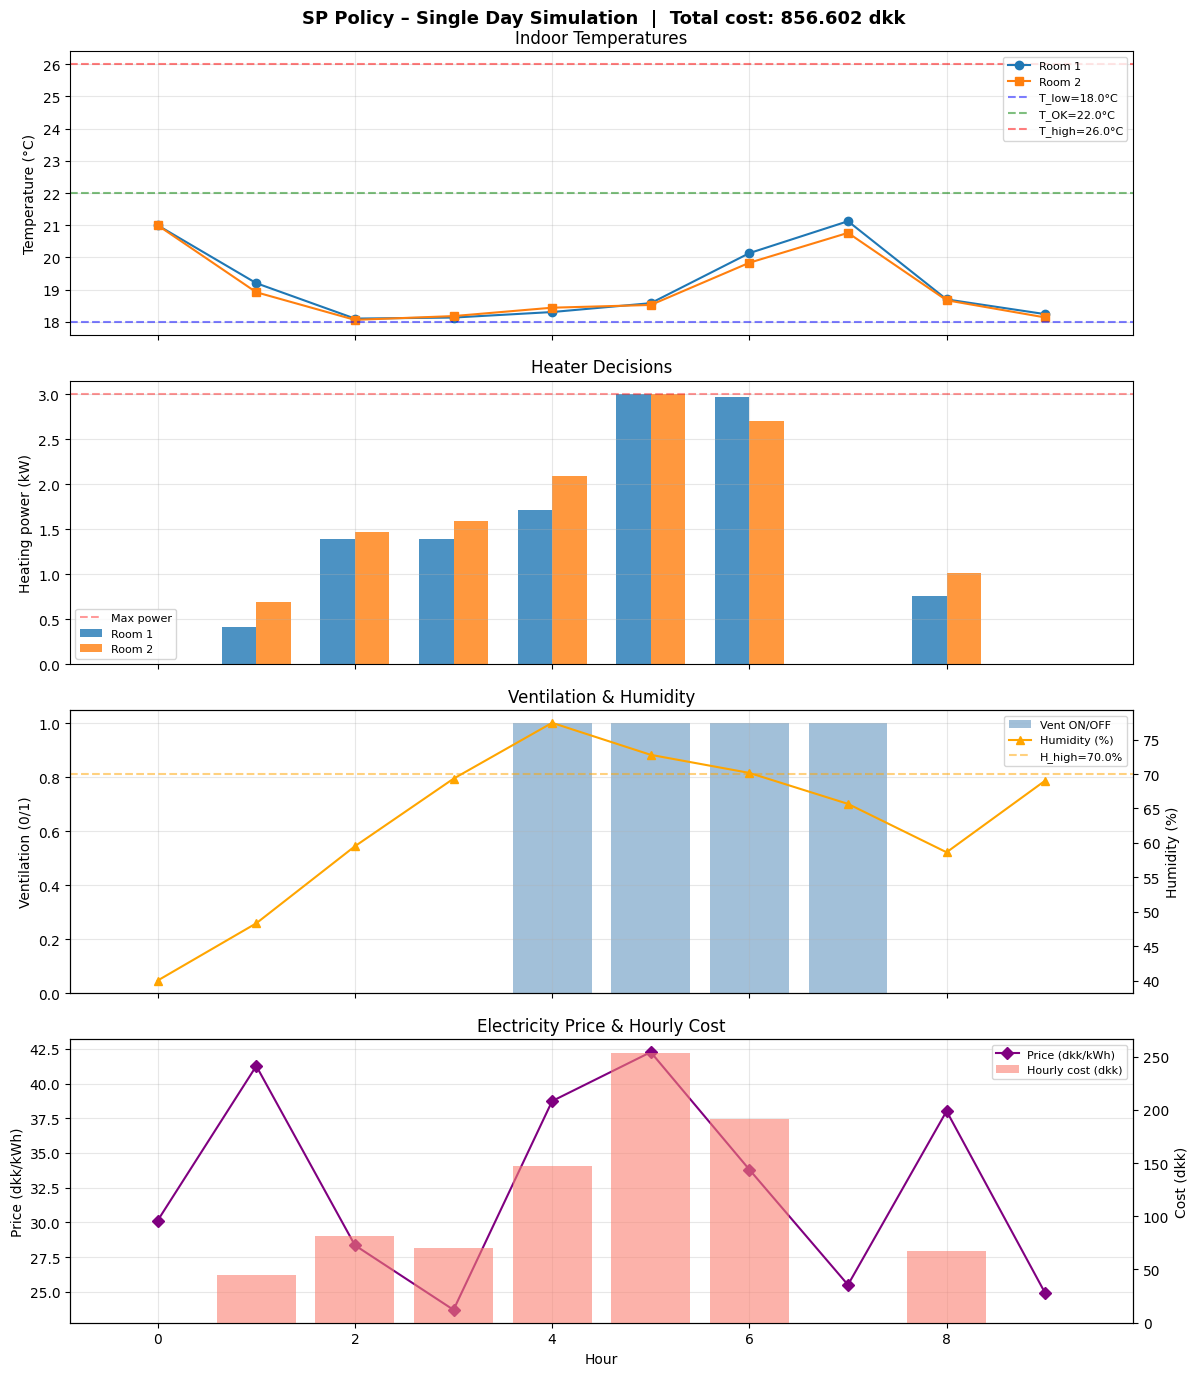

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
T_range = log['t']

# Temperatures
axes[0].plot(T_range, log['T1'], marker='o', label='Room 1')
axes[0].plot(T_range, log['T2'], marker='s', label='Room 2')
axes[0].axhline(DATA['temp_min_comfort_threshold'], ls='--', color='blue',  alpha=0.5, label=f"T_low={DATA['temp_min_comfort_threshold']}°C")
axes[0].axhline(DATA['temp_OK_threshold'],          ls='--', color='green', alpha=0.5, label=f"T_OK={DATA['temp_OK_threshold']}°C")
axes[0].axhline(DATA['temp_max_comfort_threshold'], ls='--', color='red',   alpha=0.5, label=f"T_high={DATA['temp_max_comfort_threshold']}°C")
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Indoor Temperatures')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Heating power
w = 0.35
axes[1].bar([x - w/2 for x in T_range], log['p1'], width=w, label='Room 1', alpha=0.8)
axes[1].bar([x + w/2 for x in T_range], log['p2'], width=w, label='Room 2', alpha=0.8)
axes[1].axhline(DATA['heating_max_power'], ls='--', color='red', alpha=0.4, label='Max power')
axes[1].set_ylabel('Heating power (kW)')
axes[1].set_title('Heater Decisions')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Ventilation + humidity
ax_v = axes[2]
ax_h = ax_v.twinx()
ax_v.bar(T_range, log['v'], color='steelblue', alpha=0.5, label='Vent ON/OFF')
ax_h.plot(T_range, log['H'], marker='^', color='orange', label='Humidity (%)')
ax_h.axhline(DATA['humidity_threshold'], ls='--', color='orange', alpha=0.5,
             label=f"H_high={DATA['humidity_threshold']}%")
ax_v.set_ylabel('Ventilation (0/1)')
ax_h.set_ylabel('Humidity (%)')
axes[2].set_title('Ventilation & Humidity')
lines1, labs1 = ax_v.get_legend_handles_labels()
lines2, labs2 = ax_h.get_legend_handles_labels()
ax_v.legend(lines1 + lines2, labs1 + labs2, fontsize=8)
axes[2].grid(True, alpha=0.3)

# Electricity price + cost
ax_p = axes[3]
ax_c = ax_p.twinx()
ax_p.plot(T_range, log['price'], marker='D', color='purple', label='Price (dkk/kWh)')
ax_c.bar(T_range, log['cost_t'], color='salmon', alpha=0.6, label='Hourly cost (dkk)')
ax_p.set_ylabel('Price (dkk/kWh)')
ax_c.set_ylabel('Cost (dkk)')
axes[3].set_title('Electricity Price & Hourly Cost')
axes[3].set_xlabel('Hour')
lines1, labs1 = ax_p.get_legend_handles_labels()
lines2, labs2 = ax_c.get_legend_handles_labels()
ax_p.legend(lines1 + lines2, labs1 + labs2, fontsize=8)
axes[3].grid(True, alpha=0.3)

fig.suptitle(f"SP Policy – Single Day Simulation  |  Total cost: {log['total_cost']:.3f} dkk",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



## 2 Stage vs lookahead policy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_and_compare_policies(initial_state, gen_data, policy_sp, policy_lookahead, horizon=10):
    """
    Simulates and compares the SP policy and the Lookahead policy side by side over the given horizon, 
    ensuring both policies experience the exact same exogenous scenario path.
    """
    # 1. Initialize independent states for both policies
    state_sp = initial_state.copy()
    state_look = initial_state.copy()
    
    # 2. Initialize independent logs
    log_sp = {k: [] for k in ['t','T1','T2','H','p1','p2','v','price','cost_t']}
    log_look = {k: [] for k in ['t','T1','T2','H','p1','p2','v','price','cost_t']}
    
    total_cost_sp = 0.0
    total_cost_look = 0.0
    
    # Fetch fixed system data to accurately compute ventilation costs
    d = get_fixed_data()
    vent_power = d['ventilation_power']
    
    print(f"{'Time':<5} | {'Price':<6} | {'SP Policy (Cost / T1 / T2 / H)':<38} | {'Lookahead (Cost / T1 / T2 / H)':<38}")
    print("-" * 97)
    
    for t in range(horizon):
        current_price = gen_data[0][t]
        
        # Sync exogenous variables for safety
        state_sp['price_now'] = current_price
        state_sp['occ_r1'] = gen_data[1][t]
        state_sp['occ_r2'] = gen_data[2][t]
        
        state_look['price_now'] = current_price
        state_look['occ_r1'] = gen_data[1][t]
        state_look['occ_r2'] = gen_data[2][t]
        
        # ==========================================
        # POLICY 1: STOCHASTIC PROGRAMMING (SP)
        # ==========================================
        dec_sp = policy_sp(state_sp, gen_data)
        
        # Calculate cost: (Heating_r1 + Heating_r2 + Ventilation_power) * Price
        cost_sp = (dec_sp[0] + dec_sp[1] + dec_sp[2] * vent_power) * current_price
        total_cost_sp += cost_sp
        
        # Append to SP log
        log_sp['t'].append(t)
        log_sp['T1'].append(state_sp['T_in_r1'])
        log_sp['T2'].append(state_sp['T_in_r2'])
        log_sp['H'].append(state_sp['humidity'])
        log_sp['p1'].append(dec_sp[0])
        log_sp['p2'].append(dec_sp[1])
        log_sp['v'].append(dec_sp[2])
        log_sp['price'].append(current_price)
        log_sp['cost_t'].append(cost_sp)
        
        # ==========================================
        # POLICY 2: LOOKAHEAD
        # ==========================================
        dec_look = policy_lookahead(state_look, gen_data)
        
        cost_look = (dec_look[0] + dec_look[1] + dec_look[2] * vent_power) * current_price
        total_cost_look += cost_look
        
        # Append to Lookahead log
        log_look['t'].append(t)
        log_look['T1'].append(state_look['T_in_r1'])
        log_look['T2'].append(state_look['T_in_r2'])
        log_look['H'].append(state_look['humidity'])
        log_look['p1'].append(dec_look[0])
        log_look['p2'].append(dec_look[1])
        log_look['v'].append(dec_look[2])
        log_look['price'].append(current_price)
        log_look['cost_t'].append(cost_look)
        
        # ==========================================
        # SIDE-BY-SIDE PRINTING
        # ==========================================
        sp_info   = f"${cost_sp:<6.2f} / {state_sp['T_in_r1']:<4.1f} / {state_sp['T_in_r2']:<4.1f} / {state_sp['humidity']:<4.1f}"
        look_info = f"${cost_look:<6.2f} / {state_look['T_in_r1']:<4.1f} / {state_look['T_in_r2']:<4.1f} / {state_look['humidity']:<4.1f}"
        print(f"{t:<5} | {current_price:<6.2f} | {sp_info:<38} | {look_info:<38}")
        
        # ==========================================
        # APPLY DYNAMICS (Independent Environment Updates)
        # ==========================================
        next_state_sp = apply_dynamics(state_sp, dec_sp, gen_data)
        next_state_look = apply_dynamics(state_look, dec_look, gen_data)
        
        state_sp = next_state_sp
        state_look = next_state_look

    print("-" * 97)
    print(f"{'Total':<5} | {'-':<6} | Cost: ${total_cost_sp:<29.2f} | Cost: ${total_cost_look:<29.2f}")
    
    log_sp['total_cost'] = total_cost_sp
    log_look['total_cost'] = total_cost_look
    
    # Trigger plotting function
    plot_policy_comparison(log_sp, log_look, horizon, d)
    
    return log_sp, log_look


def plot_policy_comparison(log_sp, log_look, horizon, d):
    """
    Plots the tracked trajectories of both policies side-by-side for comparison.
    """
    t_range = range(horizon)
    fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
    fig.suptitle(f"Policy Comparison\nSP Total Cost: ${log_sp['total_cost']:.2f}  |  Lookahead Total Cost: ${log_look['total_cost']:.2f}", fontsize=16)
    
    cols = [('SP Policy', log_sp), ('Lookahead Policy', log_look)]
    
    for col_idx, (title, log) in enumerate(cols):
        # 1. Temperatures
        ax_t = axes[0, col_idx]
        ax_t.set_title(f"{title} - Temperatures")
        ax_t.plot(t_range, log['T1'], label='Room 1', marker='o', color='blue')
        ax_t.plot(t_range, log['T2'], label='Room 2', marker='o', color='red')
        ax_t.axhline(d['temp_min_comfort_threshold'], color='k', linestyle='--', label='Min T')
        ax_t.axhline(d['temp_max_comfort_threshold'], color='k', linestyle='--', label='Max T')
        ax_t.set_ylabel('Temp (°C)')
        ax_t.legend(loc='best', fontsize=8)
        ax_t.grid(True, alpha=0.3)
        
        # 2. Humidity
        ax_h = axes[1, col_idx]
        ax_h.set_title(f"{title} - Humidity")
        ax_h.plot(t_range, log['H'], label='Humidity', marker='s', color='green')
        ax_h.axhline(d['humidity_threshold'], color='k', linestyle='--', label='Max Humidity')
        ax_h.set_ylabel('Humidity (%)')
        ax_h.legend(loc='best', fontsize=8)
        ax_h.grid(True, alpha=0.3)
        
        # 3. Actions (Heating & Vent)
        ax_a = axes[2, col_idx]
        ax_v = ax_a.twinx()
        ax_a.set_title(f"{title} - Actions")
        ax_a.bar([t - 0.2 for t in t_range], log['p1'], width=0.4, label='Heat R1 (kW)', color='blue', alpha=0.6)
        ax_a.bar([t + 0.2 for t in t_range], log['p2'], width=0.4, label='Heat R2 (kW)', color='red', alpha=0.6)
        ax_v.step(t_range, log['v'], where='mid', label='Ventilation (0/1)', color='green', linewidth=2)
        ax_a.set_ylabel('Power (kW)')
        ax_v.set_ylabel('Ventilation')
        ax_v.set_yticks([0, 1])
        lines1, labs1 = ax_a.get_legend_handles_labels()
        lines2, labs2 = ax_v.get_legend_handles_labels()
        ax_a.legend(lines1 + lines2, labs1 + labs2, loc='upper left', fontsize=8)
        ax_a.grid(True, alpha=0.3)
        
        # 4. Costs & Prices
        ax_c = axes[3, col_idx]
        ax_p = ax_c.twinx()
        ax_c.set_title(f"{title} - Hourly Cost & Price")
        ax_c.bar(t_range, log['cost_t'], color='salmon', alpha=0.6, label='Hourly Cost')
        ax_p.plot(t_range, log['price'], marker='D', color='purple', label='Grid Price')
        ax_c.set_ylabel('Cost ($)')
        ax_p.set_ylabel('Price ($/kWh)')
        ax_c.set_xlabel('Hour')
        lines1, labs1 = ax_c.get_legend_handles_labels()
        lines2, labs2 = ax_p.get_legend_handles_labels()
        ax_c.legend(lines1 + lines2, labs1 + labs2, loc='upper left', fontsize=8)
        ax_c.grid(True, alpha=0.3)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Time  | Price  | SP Policy (Cost / T1 / T2 / H)         | Lookahead (Cost / T1 / T2 / H)        
-------------------------------------------------------------------------------------------------
0     | 2.60   | $1.32   / 21.0 / 21.0 / 40.0           | $0.00   / 21.0 / 21.0 / 40.0          
1     | 2.80   | $13.38  / 19.3 / 19.5 / 49.6           | $12.39  / 19.2 / 19.0 / 49.6          
2     | 2.70   | $21.27  / 21.0 / 19.3 / 58.7           | $17.09  / 20.0 / 19.4 / 58.7          
3     | 3.38   | $14.60  / 20.9 / 20.9 / 55.2           | $10.99  / 20.0 / 19.5 / 55.2          
4     | 5.45   | $17.81  / 21.2 / 18.6 / 50.0           | $32.21  / 18.4 / 18.2 / 50.0          
5     | 2.40   | $19.19  / 18.7 / 18.6 / 44.9           | $6.67   / 18.6 / 18.5 / 44.9          
6     | 4.94   | $0.14   / 19.9 / 19.7 / 38.0           | $8.28   / 18.6 / 19.0 / 53.0          
7     | 5.26   | $12.29  / 18.6 / 18.7 / 47.7           | $11.28  / 18.5 / 18.6 / 62.7          
8     | 3.64   | $9.53   / 18

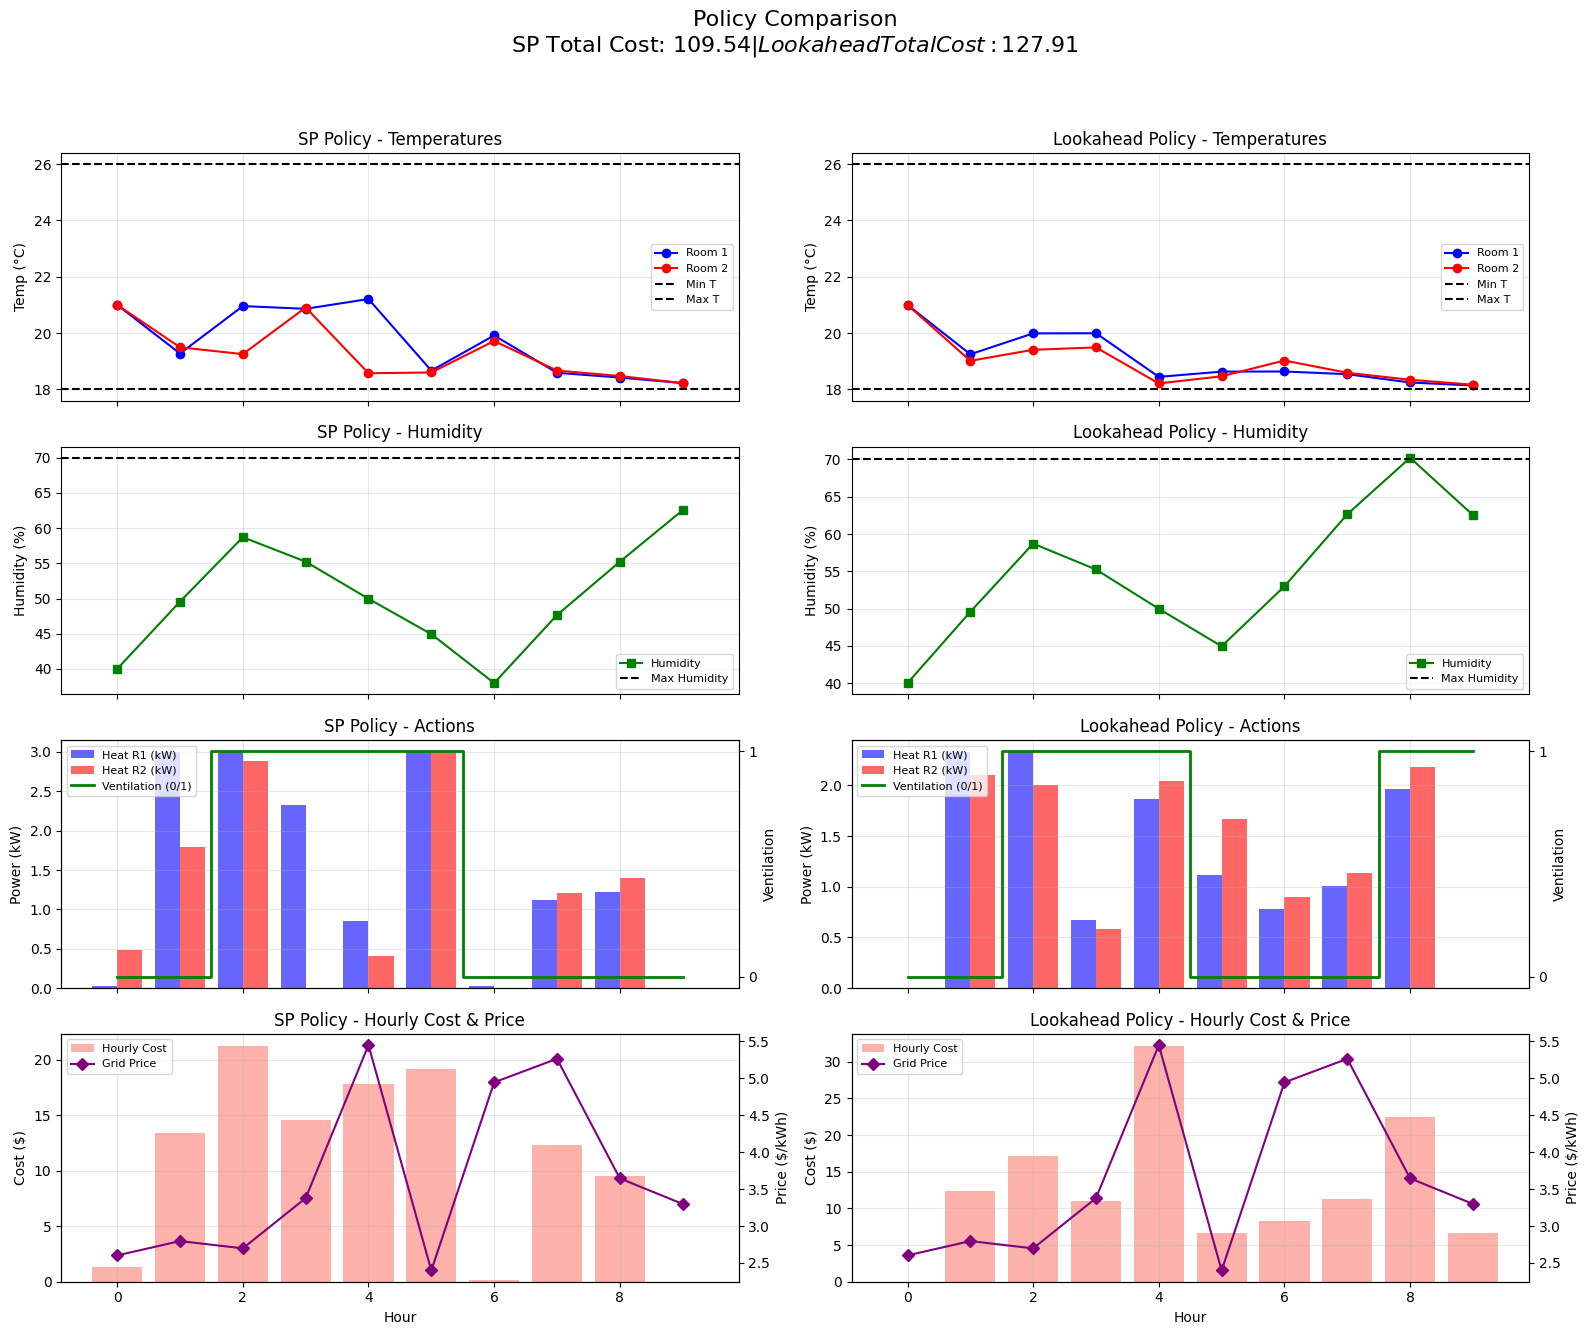

In [ ]:
# 1. Initialize reproducible data and scenarios
_rng = np.random.default_rng(seed=22)
sample_prices = [float(np.clip(_rng.normal(4, 1), 0, 12)) for _ in range(10)]
sample_occ_r1 = [float(np.clip(_rng.normal(30, 5), 20, 50)) for _ in range(10)]
sample_occ_r2 = [float(np.clip(_rng.normal(20, 4), 10, 30)) for _ in range(10)]
gen_data = sample_prices, sample_occ_r1, sample_occ_r2

# 2. Run the combined environment
log_sp, log_look = run_and_compare_policies(
    initial_state=initial_state, 
    gen_data=gen_data, 
    policy_sp=SP_policy, 
    policy_lookahead=lookahead_policy, # Replace with the exact name of your lookahead policy function
    horizon=10
)